# 🌿 Cross Domain Plant Species Identification

---

A deep learning approach for identifying plant species across different visual domains (herbarium specimens → field photographs) using **Variational Domain Disentanglement (VDD)**.

---

>  Reference Paper:
>
> Wang, Z., Luo, Y., Zhang, P.F., Wang, S. and Huang, Z., 2022, July. **Discovering domain disentanglement for generalized multi-source domain adaptation.** In *2022 IEEE International Conference on Multimedia and Expo (ICME)* (pp. 1-6). IEEE.
>
> *This implementation adapts the VDD framework for cross-domain plant species recognition, learning domain-invariant semantic features to bridge the gap between herbarium and field image domains.*

---


##  Step 1: Clone the Dataset Repository

First, we clone the GitHub repository containing our herbarium dataset. This repository includes:
- **Raw images**: Herbarium specimens and field photographs of plant species
- **Processed CSV files**: Train/validation/test splits with labels and metadata
- **Species mappings**: Mapping from label indices to scientific species names

The dataset contains **100 plant species** with images from two domains:
- **Herbarium domain** (source): Pressed plant specimens in controlled conditions
- **Field domain** (target): Natural photographs taken in the wild


In [ ]:
!git clone https://github.com/Brandenn28/ML.git

Cloning into 'ML'...
remote: Enumerating objects: 5139, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 5139 (delta 1), reused 0 (delta 0), pack-reused 5132 (from 1)
Receiving objects: 100% (5139/5139), 576.60 MiB | 36.07 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Updating files: 100% (4974/4974), done.


##  Step 2: Configure Data Paths

Here we define the paths to our processed data files:
- **`train.csv`**: Training data (herbarium + some field images)
- **`val_v2.csv`**: Validation data (field images only - our target domain)
- **`test.csv`**: Test data without ground truth labels
- **`test_with_groundtruth.csv`**: Test data with labels for final evaluation

We verify that all files exist before proceeding.


In [ ]:
import os
import pandas as pd
from PIL import Image

DATA_ROOT = "/content/ML/AML_project_herbarium_dataset"
PROC_DIR  = os.path.join(DATA_ROOT, "processed")

train_csv_path    = os.path.join(PROC_DIR, "train.csv")
val_csv_path      = os.path.join(PROC_DIR, "val_v2.csv")
test_csv_path     = os.path.join(PROC_DIR, "test.csv")
test_gt_csv_path  = os.path.join(PROC_DIR, "test_with_groundtruth.csv")

print(train_csv_path, os.path.exists(train_csv_path))
print(val_csv_path,   os.path.exists(val_csv_path))
print(test_csv_path,  os.path.exists(test_csv_path))
print(test_gt_csv_path, os.path.exists(test_gt_csv_path))

/content/ML/AML_project_herbarium_dataset/processed/train.csv True
/content/ML/AML_project_herbarium_dataset/processed/val_v2.csv True
/content/ML/AML_project_herbarium_dataset/processed/test.csv True
/content/ML/AML_project_herbarium_dataset/processed/test_with_groundtruth.csv True


##  Step 3: Define the Dataset Class

The `HerbariumDataset` class is a custom PyTorch Dataset that:

1. **Loads images** from disk based on CSV file paths
2. **Applies transforms** (augmentation, normalization)
3. **Returns domain information** (0 = herbarium, 1 = field) - crucial for the VDD model
4. **Supports sample weights** for handling class imbalance

Each sample returns:
- `image`: Preprocessed image tensor
- `label`: Species class index (0-99)
- `domain`: Domain ID (0 = herbarium, 1 = field)
- `sample_weight` (optional): Weight for balanced sampling


In [ ]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD

DOMAIN2ID = {"herbarium": 0, "field": 1}
ID2DOMAIN = {v: k for k, v in DOMAIN2ID.items()}

class HerbariumDataset(Dataset):
    def __init__(
        self,
        csv_path,
        data_root,
        transform=None,
        with_labels=True,
        sample_weights_df=None,   # optional
    ):
        """
        csv_path: processed/train.csv or val.csv or test.csv
        data_root: root of repo, e.g. /content/ML/AML_project_herbarium_dataset
        transform: torchvision transforms
        with_labels: False for pure test set if you don’t want labels
        sample_weights_df: optional DataFrame with 'abs_path' + 'sample_weight'
        """
        self.data_root = data_root
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.with_labels = with_labels
        self.transform = transform

        # If we want per-sample weights, merge by abs_path (paths match row-by-row)
        self.sample_weights = None
        if sample_weights_df is not None:
            merged = self.df.merge(
                sample_weights_df[["abs_path", "sample_weight"]],
                on="abs_path",
                how="left",
            )
            self.sample_weights = merged["sample_weight"].values

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Build image path from rel_path
        img_path = os.path.join(self.data_root, row["rel_path"])
        img = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        # Always return domain (needed for VDD-lite)
        domain_str = row.get("domain", "field")   # test.csv still has 'domain' = field
        domain_id = DOMAIN2ID[domain_str]

        if self.with_labels:
            label = int(row["label_idx"])
            out = {
                "image": img,
                "label": label,
                "domain": domain_id,
            }
        else:
            out = {
                "image": img,
                "domain": domain_id,
            }

        if self.sample_weights is not None:
            out["sample_weight"] = float(self.sample_weights[idx])

        return out

##  Step 4: Create Data Transforms and DataLoaders

### Image Transforms
- **Training transforms**: Include data augmentation (random flip, rotation) to improve generalization
- **Validation transforms**: Only resize and normalize (no augmentation for consistent evaluation)
- **Image size**: 518×518 pixels (optimal for DINOv2 ViT-B/14 backbone)
- **Normalization**: Using ImageNet mean and standard deviation

### DataLoaders
- **Batch size**: 16 images per batch
- **Shuffling**: Training data is shuffled; validation is not
- **Workers**: 2 parallel workers for efficient data loading


In [ ]:
from torch.utils.data import DataLoader

IMG_SIZE = 518

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD),
])

# Optional: load sample weights (for WeightedRandomSampler later if you want)
train_sw_df = pd.read_csv(os.path.join(PROC_DIR, "train_sample_weights.csv"))
species_map_df = pd.read_csv(os.path.join(PROC_DIR, "species_mapping.csv"))
IDX2SPECIES = species_map_df.set_index("label_idx")["species_name"].to_dict()


train_dataset = HerbariumDataset(
    csv_path=train_csv_path,
    data_root=DATA_ROOT,
    transform=train_tfms,
    with_labels=True,
    sample_weights_df=train_sw_df,   # or None if you don’t care
)

val_dataset = HerbariumDataset(
    csv_path=val_csv_path,
    data_root=DATA_ROOT,
    transform=val_tfms,
    with_labels=True,
)

batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,          # or use WeightedRandomSampler with sample_weight
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)


###  Alternative: Weighted Random Sampling (Optional)

The commented code below shows how to use `WeightedRandomSampler` instead of regular shuffling. This helps address **class imbalance** by sampling rare classes more frequently during training.


In [ ]:
#If you want WeightedRandomSampler using sample_weight, you can do:
#from torch.utils.data import WeightedRandomSampler
#import numpy as np

#weights = train_dataset.sample_weights
#sampler = WeightedRandomSampler(
#    weights=torch.DoubleTensor(weights),
#    num_samples=len(weights),
#    replacement=True,
#)
#
#train_loader = DataLoader(
#    train_dataset,
#    batch_size=batch_size,
#    sampler=sampler,
#    num_workers=2,
#    pin_memory=True,
#)


##  Step 5: Define Loss Hyperparameters (Lambda Values)

The VDD model uses multiple loss functions, each with its own weight (λ):

| Loss Term | Target λ | Purpose |
|-----------|----------|---------|
| **Reconstruction** | 0.01 | Forces the model to preserve image information in embeddings |
| **Domain (zs)** | 0.1 | Adversarial loss to make zs domain-invariant via GRL |
| **Domain (zd)** | 0.1 | Ensures domain embedding captures domain-specific info |

### Warmup Strategy
- **Start epoch**: Loss terms activate at epoch 2
- **Warmup period**: 5 epochs to gradually reach full strength
- **Reason**: Allows the classifier to stabilize before adding auxiliary losses


In [ ]:
LAMBDA_RECON_TARGET = 0.01
LAMBDA_DOM_ZS_TARGET = 0.1
LAMBDA_DOM_ZD_TARGET = 0.1
LAMBDA_WARMUP_START = 2      # start applying at epoch 2
LAMBDA_WARMUP_EPOCHS = 5     # reach full strength by epoch 7

##  Step 6: Visualize a Training Batch

Let's verify our data pipeline is working correctly by visualizing a batch:
- Check tensor shapes (should be `[batch_size, 3, 518, 518]`)
- Verify labels are in expected range (0-99)
- Confirm domain IDs are correct (0=herbarium, 1=field)

> ⚠️ **Note**: The matplotlib warning about clipping is expected because we're displaying normalized tensors. The image looks correct despite the warning.


Batch shape: torch.Size([16, 3, 518, 518])
Labels: [94, 88, 10, 76, 34, 72, 86, 98]
Domains: [0, 1, 0, 0, 0, 0, 0, 1]


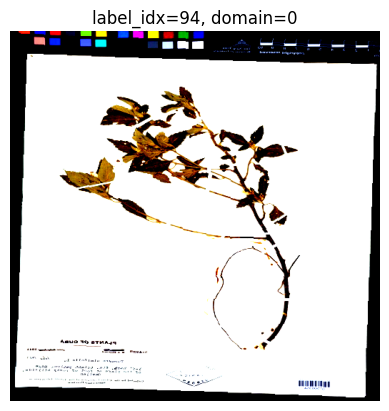

In [ ]:
import matplotlib.pyplot as plt

batch = next(iter(train_loader))
imgs = batch["image"]
labels = batch["label"]
domains = batch["domain"]

print("Batch shape:", imgs.shape)
print("Labels:", labels[:8].tolist())
print("Domains:", domains[:8].tolist())  # 0=herbarium, 1=field

# show first image
img0 = imgs[0].permute(1, 2, 0).cpu().numpy()
plt.imshow(img0)
plt.title(f"label_idx={labels[0].item()}, domain={domains[0].item()}")
plt.axis("off")
plt.show()


##  Step 7: Set Up Device (GPU/CPU)

Configure PyTorch to use GPU (CUDA) if available, otherwise fall back to CPU.


In [ ]:
import os
import math
import time
import copy

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

##  Step 8: Define the VDD Model Architecture

### VDDLiteHerbarium - Variational Domain Disentanglement Model

This is the core model architecture implementing the VDD approach:

```
Input Image → DINOv2 Backbone → Sample Embedding (zs) → Classifier → Species Prediction
                                      ↓
                              + Domain Embedding (zd)
                                      ↓
                                   Decoder → Reconstructed Image
```

### Key Components:

1. **Backbone (DINOv2 ViT-B/14)**
   - Pre-trained Vision Transformer for powerful feature extraction
   - Outputs 768-dimensional feature vectors

2. **Sample Head (zs)**
   - Projects backbone features to 512-dim **domain-invariant** embedding
   - Used for species classification

3. **Domain Embedding (zd)**
   - Learnable 32-dim embedding for each domain (herbarium/field)
   - Captures **domain-specific** information

4. **Gradient Reversal Layer (GRL)**
   - Applied to zs before domain classification
   - Adversarially trains zs to be domain-invariant
   - Key innovation: makes features transferable across domains

5. **Decoder**
   - Reconstructs image from [zs; zd]
   - Ensures embeddings preserve essential information

### Why This Works for Cross-Domain Transfer:
- **zs learns domain-invariant features** → generalizes to unseen domain (field images)
- **zd captures domain-specific variations** → disentangles domain from content
- **GRL adversarial training** → forces classifier to ignore domain differences


In [ ]:
import timm

class GradReverseFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None

def grad_reverse(x, lambd=1.0):
    return GradReverseFn.apply(x, lambd)


class VDDLiteHerbarium(nn.Module):
    """
    VDD-inspired model:
    - DINOv2 backbone → sample embedding zs (domain-invariant)
    - Domain embedding zd (2 domains)
    - Classifier on zs (species prediction)
    - Domain classifiers on zs (with GRL) and zd
    - Decoder to reconstruct image from [zs; zd]
    """
    def __init__(self, num_classes=100, grl_lambda=1.0, img_size=128):
        super().__init__()
        self.grl_lambda = grl_lambda
        self.img_size = img_size

        # Backbone
        self.backbone = timm.create_model(
            "vit_base_patch14_dinov2",
            pretrained=True,
            num_classes=0,      # ensure forward returns pooled features

        )
        feat_dim = self.backbone.num_features  # e.g. 768 or 1024

        self.sample_head = nn.Sequential(
            nn.Linear(feat_dim, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 512)
        )

        # Domain embedding (domain-specific)
        self.domain_emb = nn.Embedding(2, 32)  # 0=herbarium, 1=field

        # Classifier on zs
        self.classifier = nn.Linear(512, num_classes)

        # Domain classifiers
        self.domain_clf_zs = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 2)
        )
        self.domain_clf_zd = nn.Linear(32, 2)

        # Decoder
        latent_dim = 512 + 32
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 8 * 8 * 256),
            nn.ReLU(inplace=True),
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        if hasattr(self.backbone, "forward_features"):
            feat = self.backbone.forward_features(x)
        else:
            feat = self.backbone(x)

        # Handle different output types
        if hasattr(feat, "last_hidden_state"):
            feat = feat.last_hidden_state  # (B, T, D)
        elif isinstance(feat, dict):
            if "x_norm_clstoken" in feat:
                feat = feat["x_norm_clstoken"]        # (B, D)
            elif "pool" in feat:
                feat = feat["pool"]                   # (B, D)
            else:
                feat = list(feat.values())[0]

        if feat.ndim == 3:
            feat = feat[:, 0, :]
        if feat.ndim == 4:
            feat = feat.mean(dim=[2, 3])

        zs = self.sample_head(feat)       # (B, 512)
        return zs



    def decode(self, zs, zd):
        z = torch.cat([zs, zd], dim=1)   # (B, 544)
        h = self.decoder_fc(z)           # (B, 8*8*256)
        h = h.view(-1, 256, 8, 8)
        x_hat = self.decoder_conv(h)     # (B, 3, 128, 128)
        return x_hat

    def forward(self, x, d):
        """
        x: (B, 3, H, W)
        d: (B,) domain ids ∈ {0,1}
        """
        zs = self.encode(x)
        zd = self.domain_emb(d)          # (B, 32)

        if not hasattr(self, "_debug_printed"):
            print("DEBUG zs mean:", zs.mean().item(), "std:", zs.std().item())
            self._debug_printed = True


        logits_cls = self.classifier(zs)

        # Domain prediction from zs (with GRL)
        zs_rev = grad_reverse(zs, self.grl_lambda)
        logits_domain_zs = self.domain_clf_zs(zs_rev)

        # Domain prediction from zd (no GRL)
        logits_domain_zd = self.domain_clf_zd(zd)

        # Reconstruction
        x_hat = self.decode(zs, zd)

        return {
            "logits_cls": logits_cls,
            "logits_domain_zs": logits_domain_zs,
            "logits_domain_zd": logits_domain_zd,
            "x_hat": x_hat,
            "zs": zs,
            "zd": zd,
        }

##  Step 9: Load Class Weights for Imbalanced Classification

The dataset has **class imbalance** (some species have many more images than others). We use **inverse frequency weighting** in the cross-entropy loss:
- Rare classes get higher weights → penalize misclassifying them more
- Common classes get lower weights → reduce their dominance

This helps the model learn to recognize rare species instead of just predicting common ones.


In [ ]:
class_weights_path = os.path.join(PROC_DIR, "class_weights.csv")
cw_df = pd.read_csv(class_weights_path)
print(cw_df.head())

# columns are: 'label_idx', 'weight_inv'
num_classes = cw_df["label_idx"].max() + 1

class_weights = torch.zeros(num_classes, dtype=torch.float32)

for _, row in cw_df.iterrows():
    class_weights[int(row["label_idx"])] = float(row["weight_inv"])

# (optional) normalise to mean 1.0 – not necessary but can help
class_weights = class_weights / class_weights.mean()

class_weights = class_weights.to(device)
class_weights

   label_idx  weight_inv
0          0    0.038462
1          1    0.025000
2          2    0.025000
3          3    0.025000
4          4    0.025000


tensor([1.4065, 0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 0.9143,
        0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 0.9143,
        0.9143, 0.9143, 0.9143, 1.8285, 0.9143, 0.9143, 0.9143, 1.2190, 0.9143,
        0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 0.9143,
        0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 1.1428, 0.9143, 0.9143,
        1.1428, 0.9143, 1.9247, 0.9143, 0.9143, 0.9143, 0.9143, 1.4628, 0.9143,
        0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 0.9884, 2.0317, 0.9143,
        0.9143, 0.9143, 0.9143, 2.0317, 0.9143, 0.9143, 0.9143, 0.9143, 0.9143,
        0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 1.0756, 0.9143, 0.9143, 1.8285,
        0.9143, 1.8285, 0.9143, 0.9143, 1.4628, 0.9143, 0.9143, 0.9143, 0.9143,
        0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 0.9143, 0.9143,
        0.9143], device='cuda:0')

##  Step 10: Define Accuracy Metric Function

The `accuracy_topk` function computes **Top-K accuracy**:

- **Top-1 Accuracy**: Is the correct class the model's #1 prediction?
- **Top-5 Accuracy**: Is the correct class among the model's top 5 predictions?

### Formula:
$$\text{Top-N Accuracy} = \frac{\text{Samples where ground truth is in top N predictions}}{\text{Total samples}} \times 100\%$$

Top-5 is especially important for plant identification where visually similar species exist.


In [ ]:
def accuracy_topk(logits, targets, topk=(1,5)):
    """
    Returns a dict {1: top1, 5: top5} in percentage.
    """
    with torch.no_grad():
        maxk = max(topk)
        batch_size = targets.size(0)

        _, pred = logits.topk(maxk, dim=1, largest=True, sorted=True)
        pred = pred.t()  # (maxk, B)
        correct = pred.eq(targets.view(1, -1).expand_as(pred))

        res = {}
        for k in topk:
            correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
            res[k] = (correct_k / batch_size).item() * 100.0
        return res


##  Step 11: Define Warmup Function

The `warmup_value` function implements **linear warmup** for loss weights:
- Starts at 0 at the beginning of training
- Linearly increases to the target value over several epochs

### Why Warmup?
1. Lets the classifier stabilize first before adding auxiliary losses
2. Prevents unstable training in early epochs
3. Gradual introduction of domain adversarial training


In [ ]:
def warmup_value(epoch, target_value, start_epoch=1, warmup_epochs=5):
    """
    Linearly increases a value from 0 to target_value starting at start_epoch
    across warmup_epochs. Epoch indexing is 1-based.
    """
    if epoch <= start_epoch:
        return 0.0
    progress = min(1.0, (epoch - start_epoch) / max(1, warmup_epochs))
    return target_value * progress

##  Step 12: Define Training and Evaluation Functions

### `train_one_epoch` Function
Performs one complete pass through the training data:

1. **Forward pass**: Get predictions and embeddings from model
2. **Compute losses**:
   - `loss_cls`: Cross-entropy for species classification (main objective)
   - `loss_recon`: L1 reconstruction loss (preserve information)
   - `loss_dom_zs`: Domain classification on zs with GRL (adversarial)
   - `loss_dom_zd`: Domain classification on zd (supervision)
3. **Combined loss**: `loss = loss_cls + λ_recon × loss_recon + λ_dom_zs × loss_dom_zs + λ_dom_zd × loss_dom_zd`
4. **Backward pass**: Update model weights
5. **Track metrics**: Running loss and accuracy

### `evaluate` Function
Evaluates model on validation/test data:
- No gradient computation (inference mode)
- Only computes classification loss and accuracy
- Used to track generalization performance


In [ ]:
def train_one_epoch(
    model,
    train_loader,
    optimizer,
    device,
    criterion_cls,
    criterion_dom,
    lambda_recon=0.01,
    lambda_dom_zs=0.1,
    lambda_dom_zd=0.1,
):
    model.train()
    running_loss = 0.0
    running_top1 = 0.0
    running_top5 = 0.0
    total_samples = 0

    for batch in train_loader:
        x = batch["image"].to(device)
        y = batch["label"].to(device)
        d = batch["domain"].to(device)

        out = model(x, d)

        loss_cls = criterion_cls(out["logits_cls"], y)
        # Make sure shapes match for recon loss
        x_hat = out["x_hat"]                     # (B, 3, H_dec, W_dec)
        x_resized = F.interpolate(
            x, size=x_hat.shape[-2:], mode="bilinear", align_corners=False
        )
        loss_recon = F.l1_loss(x_hat, x_resized)

        loss_dom_zd = criterion_dom(out["logits_domain_zd"], d)
        loss_dom_zs = criterion_dom(out["logits_domain_zs"], d)

        loss = (
            loss_cls
            + lambda_recon * loss_recon
            + lambda_dom_zd * loss_dom_zd
            + lambda_dom_zs * loss_dom_zs
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bsz = x.size(0)
        total_samples += bsz
        running_loss += loss.item() * bsz

        accs = accuracy_topk(out["logits_cls"], y, topk=(1,5))
        running_top1 += accs[1] * bsz / 100.0
        running_top5 += accs[5] * bsz / 100.0

    epoch_loss = running_loss / total_samples
    epoch_top1 = (running_top1 / total_samples) * 100.0
    epoch_top5 = (running_top5 / total_samples) * 100.0

    return epoch_loss, epoch_top1, epoch_top5


def evaluate(model, val_loader, device, criterion_cls):
    model.eval()
    running_loss = 0.0
    running_top1 = 0.0
    running_top5 = 0.0
    total_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            x = batch["image"].to(device)
            y = batch["label"].to(device)
            d = batch["domain"].to(device)  # will be all 'field' for val

            out = model(x, d)

            loss_cls = criterion_cls(out["logits_cls"], y)

            bsz = x.size(0)
            total_samples += bsz
            running_loss += loss_cls.item() * bsz

            accs = accuracy_topk(out["logits_cls"], y, topk=(1,5))
            running_top1 += accs[1] * bsz / 100.0
            running_top5 += accs[5] * bsz / 100.0

    epoch_loss = running_loss / total_samples
    epoch_top1 = (running_top1 / total_samples) * 100.0
    epoch_top5 = (running_top5 / total_samples) * 100.0

    return epoch_loss, epoch_top1, epoch_top5

##  Step 13: Training Loop

This cell runs the main training process:

### Setup:
- **Model**: VDDLiteHerbarium with 100 classes
- **Loss**: Cross-entropy with class weights (for classification) + auxiliary losses
- **Optimizer**: Adam with lr=1e-4 and weight decay=1e-4
- **Scheduler**: ReduceLROnPlateau (reduces lr when validation loss plateaus)
- **Epochs**: 40 total

### Per-Epoch Process:
1. **Warmup GRL strength**: λ_grl increases from 0→1 over first 10 epochs
2. **Warmup loss weights**: λ_recon, λ_dom gradually increase
3. **Train**: One pass through training data
4. **Validate**: Evaluate on field-only validation set
5. **Save best**: Keep checkpoint with highest validation Top-1 accuracy
6. **Adjust lr**: Reduce learning rate if validation loss doesn't improve

### Expected Output:
- Training accuracy will increase steadily
- Validation accuracy on field images shows true generalization
- Best model saved when validation Top-1 improves


In [ ]:
num_classes = cw_df["label_idx"].nunique()
model = VDDLiteHerbarium(num_classes=num_classes, grl_lambda=1.0, img_size=IMG_SIZE)
model = model.to(device)

criterion_cls = nn.CrossEntropyLoss(weight=class_weights)
criterion_dom = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

num_epochs = 40

best_val_top1 = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(1, num_epochs + 1):
    print(f"Epoch {epoch}/{num_epochs}")

    # Warm-up GRL strength: 0.0 → 1.0 over first 10 epochs
    model.grl_lambda = min(1.0, epoch / 10.0)

    lambda_recon = warmup_value(
        epoch,
        LAMBDA_RECON_TARGET,
        start_epoch=LAMBDA_WARMUP_START,
        warmup_epochs=LAMBDA_WARMUP_EPOCHS,
    )
    lambda_dom_zs = warmup_value(
        epoch,
        LAMBDA_DOM_ZS_TARGET,
        start_epoch=LAMBDA_WARMUP_START,
        warmup_epochs=LAMBDA_WARMUP_EPOCHS,
    )
    lambda_dom_zd = warmup_value(
        epoch,
        LAMBDA_DOM_ZD_TARGET,
        start_epoch=LAMBDA_WARMUP_START,
        warmup_epochs=LAMBDA_WARMUP_EPOCHS,
    )
    print(
        f"  Warmup λ: recon={lambda_recon:.4f}, dom_zs={lambda_dom_zs:.4f}, dom_zd={lambda_dom_zd:.4f}"
    )

    train_loss, train_top1, train_top5 = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device,
        criterion_cls,
        criterion_dom,
        lambda_recon=lambda_recon,
        lambda_dom_zs=lambda_dom_zs,
        lambda_dom_zd=lambda_dom_zd,
    )

    val_loss, val_top1, val_top5 = evaluate(
        model,
        val_loader,
        device,
        criterion_cls,
    )

    scheduler.step(val_loss)

    print(
        f"  Train | loss: {train_loss:.4f} | top1: {train_top1:.2f}% | top5: {train_top5:.2f}%"
    )
    print(
        f"  Val   | loss: {val_loss:.4f} | top1: {val_top1:.2f}% | top5: {val_top5:.2f}%"
    )

    # save best based on val top-1
    if val_top1 > best_val_top1:
        best_val_top1 = val_top1
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, "/content/vdd_herbarium_best.pth")
        print("Best model saved.")

print("Training done. Best val top-1: {:.2f}%".format(best_val_top1))

model.load_state_dict(best_model_wts)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Epoch 1/40
  Warmup λ: recon=0.0000, dom_zs=0.0000, dom_zd=0.0000
DEBUG zs mean: -0.0033011166378855705 std: 0.39529654383659363
  Train | loss: 4.5972 | top1: 0.84% | top5: 5.45%
  Val   | loss: 4.4465 | top1: 2.22% | top5: 10.02%
Best model saved.
Epoch 2/40
  Warmup λ: recon=0.0000, dom_zs=0.0000, dom_zd=0.0000
  Train | loss: 4.4639 | top1: 1.84% | top5: 9.56%
  Val   | loss: 4.3804 | top1: 2.22% | top5: 11.29%
Epoch 3/40
  Warmup λ: recon=0.0020, dom_zs=0.0200, dom_zd=0.0200
  Train | loss: 4.3924 | top1: 2.00% | top5: 10.67%
  Val   | loss: 4.2530 | top1: 3.59% | top5: 13.29%
Best model saved.
Epoch 4/40
  Warmup λ: recon=0.0040, dom_zs=0.0400, dom_zd=0.0400
  Train | loss: 4.3057 | top1: 3.00% | top5: 12.25%
  Val   | loss: 4.2525 | top1: 3.69% | top5: 14.98%
Best model saved.
Epoch 5/40
  Warmup λ: recon=0.0060, dom_zs=0.0600, dom_zd=0.0600
  Train | loss: 4.2082 | top1: 3.53% | top5: 15.91%
  Val   | loss: 4.1261 | top1: 4.22% | top5: 19.41%
Best model saved.
Epoch 6/40
  Warm

<All keys matched successfully>

##  Step 14: Evaluate on Test Set

Now we evaluate the best trained model on the **held-out test set** (field images with ground truth labels).

This gives us the final performance metrics:
- **Top-1 Accuracy**: How often the model's #1 prediction is correct
- **Top-5 Accuracy**: How often the correct species is in the top 5 predictions

> 📌 **Note**: Test set performance is the true measure of cross-domain generalization - these are field images the model has never seen during training.


In [ ]:
test_dataset = HerbariumDataset(
    csv_path=test_gt_csv_path,
    data_root=DATA_ROOT,
    transform=val_tfms,
    with_labels=True,   # you *do* have groundtruth in processed/test.csv
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_loss, test_top1, test_top5 = evaluate(
    model,
    test_loader,
    device,
    criterion_cls,
)

print(
    f"Test | loss: {test_loss:.4f} | top1: {test_top1:.2f}% | top5: {test_top5:.2f}%"
)


Test | loss: 6.1745 | top1: 26.09% | top5: 45.89%


##  Step 15: Single Image Inference Helper

These utility functions allow you to **predict on individual images**:

### `predict_single_image`
- Takes a single image path and returns top-K species predictions
- Supports both herbarium (domain=0) and field (domain=1) images
- Returns species name, label index, and confidence score

### `visualize_prediction`
- Displays the image with top predictions overlaid
- Shows confidence percentages for each prediction

**Usage**: Perfect for testing the model on new images or building a demo interface.


In [ ]:
# ========== Single Image Inference Helper ==========

def predict_single_image(
    image_path,
    model,
    transform,
    idx2species,
    device,
    domain_id=1,  # default to field (1), use 0 for herbarium
    top_k=5,
):
    """
    Load and predict on a single image.

    Args:
        image_path: path to the image file
        model: trained VDDLiteHerbarium model
        transform: preprocessing transforms (use val_tfms)
        idx2species: dict mapping label_idx → species_name
        device: torch device
        domain_id: 0=herbarium, 1=field
        top_k: number of top predictions to return

    Returns:
        List of tuples: [(species_name, label_idx, confidence_score), ...]
    """
    model.eval()

    # Load and preprocess image
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)  # (1, 3, H, W)

    # Domain tensor
    d = torch.tensor([domain_id], dtype=torch.long).to(device)

    # Inference
    with torch.no_grad():
        out = model(img_tensor, d)
        logits = out["logits_cls"]  # (1, num_classes)
        probs = torch.softmax(logits, dim=1)[0]  # (num_classes,)

    # Get top-k predictions
    top_probs, top_indices = torch.topk(probs, k=min(top_k, len(probs)))

    results = []
    for prob, idx in zip(top_probs.cpu().numpy(), top_indices.cpu().numpy()):
        species = idx2species.get(int(idx), f"Unknown_{idx}")
        results.append((species, int(idx), float(prob)))

    return results


def visualize_prediction(image_path, predictions, show_image=True):
    """
    Print and optionally display prediction results.

    Args:
        image_path: path to the image
        predictions: list of (species_name, label_idx, confidence) from predict_single_image
        show_image: whether to display the image with matplotlib
    """
    print(f"\nPredictions for: {image_path}")
    print("-" * 70)
    for i, (species, label_idx, conf) in enumerate(predictions, 1):
        print(f"{i}. {species:40s} (label={label_idx:3d})  {conf*100:5.2f}%")
    print("-" * 70)

    if show_image:
        img = Image.open(image_path).convert("RGB")
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis("off")

        # Annotate with top prediction
        top_species, _, top_conf = predictions[0]
        plt.title(f"Top: {top_species} ({top_conf*100:.1f}%)", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()


# Example usage:
# predictions = predict_single_image(
#     image_path="/content/ML/AML_project_herbarium_dataset/test/290.jpg",
#     model=model,
#     transform=val_tfms,
#     idx2species=IDX2SPECIES,
#     device=device,
#     domain_id=1,  # field image
#     top_k=5,
# )
# visualize_prediction("/content/ML/AML_project_herbarium_dataset/test/290.jpg", predictions)

### 🖼️ Example: Predict on a Test Image

Running inference on a sample test image to see the model's predictions.

The output shows:
- Top-5 most likely species with confidence percentages
- The prediction is correct if the true species appears in this list (especially at rank #1 for Top-1 accuracy)



Predictions for: /content/ML/AML_project_herbarium_dataset/test/1745.jpg
----------------------------------------------------------------------
1. Annona muricata L.                       (label=  7)  39.14%
2. Annona glabra L.                         (label=  6)  34.62%
3. Tapirira guianensis Aubl.                (label=  3)  11.96%
4. Ocotea puberula (Rich.) Nees             (label= 73)   7.96%
5. Eichhornia crassipes (Mart.) Solms       (label= 96)   4.76%
----------------------------------------------------------------------


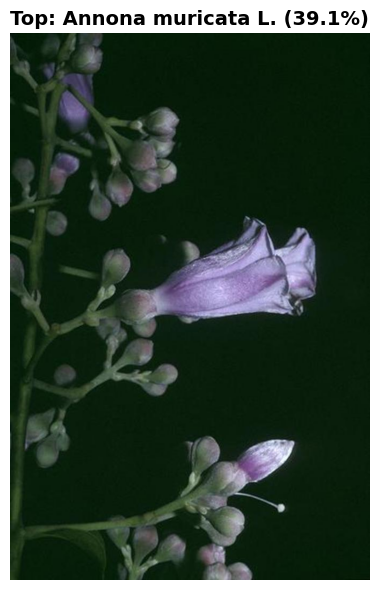

In [ ]:
predictions = predict_single_image(
     image_path="/content/ML/AML_project_herbarium_dataset/test/16286.jpg",
     model=model,
     transform=val_tfms,
     idx2species=IDX2SPECIES,
     device=device,
     domain_id=1,  # field image
     top_k=5,
 )
visualize_prediction("/content/ML/AML_project_herbarium_dataset/test/1745.jpg", predictions)

##  Step 16: Training History Visualization and Overfitting Analysis

This comprehensive visualization function provides:

### 4 Key Plots:
1. **Loss Curves**: Train vs Validation loss over epochs
2. **Top-1 Accuracy**: Train vs Validation accuracy (primary metric)
3. **Top-5 Accuracy**: Train vs Validation (should be higher than Top-1)
4. **Overfitting Analysis**: Gap between train and validation accuracy

### Overfitting Assessment:
- **< 5% gap**: ✅ Healthy - model generalizes well
- **5-10% gap**: ⚠️ Moderate - some overfitting
- **> 10% gap**: ❌ High - significant overfitting, model memorizing training data

### Key Insights:
- Green dashed line marks the best epoch (highest validation accuracy)
- If validation peaks then declines → early stopping would help
- Large loss divergence indicates the model is memorizing training patterns


Using device: cuda

VDD HERBARIUM MODEL - TEST SET EVALUATION

✓ Loaded species mapping: 100 classes
✓ Loading model from: /content/vdd_herbarium_best(40e).pth


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

✓ Model loaded successfully on cuda
✓ Test dataset loaded: 207 images

EVALUATING MODEL ON TEST SET


Testing: 100%|██████████| 7/7 [00:21<00:00,  3.08s/it]



OVERALL RESULTS
Total samples: 207
Top-1 Accuracy: 26.09% (54/207 correct)
Top-5 Accuracy: 45.89% (95/207 correct)

PER-CLASS ACCURACY

📊 Top 10 Best Performing Classes:
                                       species_name  total  top1_correct  top1_acc  top5_acc
label                                                                                       
26                          Sloanea grandiflora Sm.      2             2    1.0000    1.0000
8                   Guatteria ouregou (Aubl.) Dunal      2             2    1.0000    1.0000
46     Chrysothemis pulchella (Donn ex Sims) Decne.      3             3    1.0000    1.0000
51            Heliconia chartacea Lane ex Barreiros      2             2    1.0000    1.0000
81                            Erythrina fusca Lour.      2             2    1.0000    1.0000
88                            Adansonia digitata L.      3             3    1.0000    1.0000
99                     Cassipourea guianensis Aubl.      3             3    1.0000   

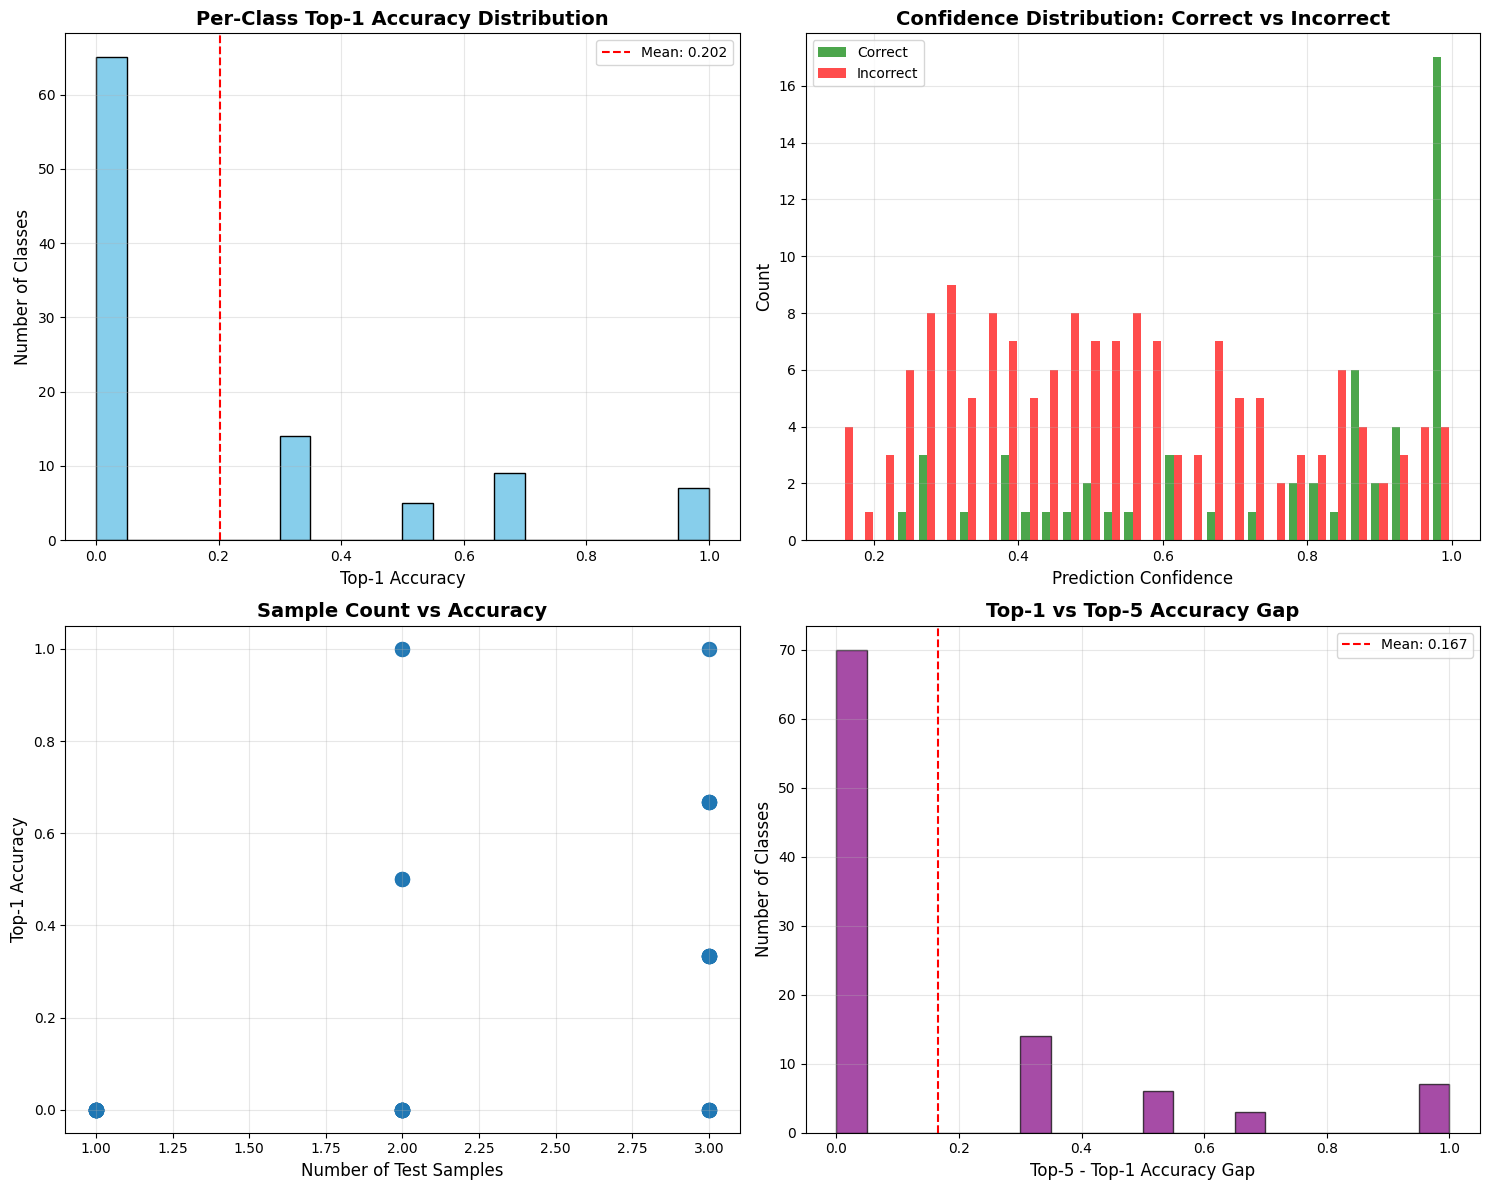


✓ Results saved to:
  - test_results_detailed.csv
  - test_results_per_class.csv

EVALUATION COMPLETE!
🎯 Final Test Accuracy:
   Top-1: 26.09%
   Top-5: 45.89%



In [ ]:
"""
Model Accuracy Testing Script for Google Colab
===============================================

This script loads your trained VDD model and evaluates it on the test set,
calculating Top-1 and Top-5 accuracy with detailed per-class breakdowns.

Usage in Colab:
    1. Upload this file or copy-paste into a cell
    2. Ensure model checkpoint and data are accessible
    3. Run the script
"""

import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD
from PIL import Image
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================================
# CONFIGURATION
# ============================================================================

# Paths (adjust for your Colab environment)
DATA_ROOT = "/content/ML/AML_project_herbarium_dataset"
PROC_DIR = os.path.join(DATA_ROOT, "processed")
MODEL_PATH = "/content/vdd_herbarium_best(40e).pth"  # Your checkpoint

# Test data
TEST_CSV = os.path.join(PROC_DIR, "test_with_groundtruth.csv")
SPECIES_MAPPING_CSV = os.path.join(PROC_DIR, "species_mapping.csv")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ============================================================================
# MODEL ARCHITECTURE (Copy from training code)
# ============================================================================

class GradReverseFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None

def grad_reverse(x, lambd=1.0):
    return GradReverseFn.apply(x, lambd)


class VDDLiteHerbarium(nn.Module):
    def __init__(self, num_classes=100, grl_lambda=1.0, img_size=518):
        super().__init__()
        self.grl_lambda = grl_lambda
        self.img_size = img_size

        self.backbone = timm.create_model(
            "vit_base_patch14_dinov2",
            pretrained=True,
            num_classes=0,
        )
        feat_dim = self.backbone.num_features

        self.sample_head = nn.Sequential(
            nn.Linear(feat_dim, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 512)
        )

        self.domain_emb = nn.Embedding(2, 32)
        self.classifier = nn.Linear(512, num_classes)

        self.domain_clf_zs = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 2)
        )
        self.domain_clf_zd = nn.Linear(32, 2)

        latent_dim = 512 + 32
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 8 * 8 * 256),
            nn.ReLU(inplace=True),
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        if hasattr(self.backbone, "forward_features"):
            feat = self.backbone.forward_features(x)
        else:
            feat = self.backbone(x)

        if hasattr(feat, "last_hidden_state"):
            feat = feat.last_hidden_state
        elif isinstance(feat, dict):
            if "x_norm_clstoken" in feat:
                feat = feat["x_norm_clstoken"]
            elif "pool" in feat:
                feat = feat["pool"]
            else:
                feat = list(feat.values())[0]

        if feat.ndim == 3:
            feat = feat[:, 0, :]
        if feat.ndim == 4:
            feat = feat.mean(dim=[2, 3])

        zs = self.sample_head(feat)
        return zs

    def decode(self, zs, zd):
        z = torch.cat([zs, zd], dim=1)
        h = self.decoder_fc(z)
        h = h.view(-1, 256, 8, 8)
        x_hat = self.decoder_conv(h)
        return x_hat

    def forward(self, x, d):
        zs = self.encode(x)
        zd = self.domain_emb(d)
        logits_cls = self.classifier(zs)

        zs_rev = grad_reverse(zs, self.grl_lambda)
        logits_domain_zs = self.domain_clf_zs(zs_rev)
        logits_domain_zd = self.domain_clf_zd(zd)
        x_hat = self.decode(zs, zd)

        return {
            "logits_cls": logits_cls,
            "logits_domain_zs": logits_domain_zs,
            "logits_domain_zd": logits_domain_zd,
            "x_hat": x_hat,
            "zs": zs,
            "zd": zd,
        }


# ============================================================================
# DATASET
# ============================================================================

DOMAIN2ID = {"herbarium": 0, "field": 1}

class TestDataset(torch.utils.data.Dataset):
    def __init__(self, csv_path, data_root, transform=None):
        self.data_root = data_root
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.data_root, row["rel_path"])
        img = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        domain_str = row.get("domain", "field")
        domain_id = DOMAIN2ID[domain_str]
        label = int(row["label_idx"])

        return {
            "image": img,
            "label": label,
            "domain": domain_id,
            "species_name": row.get("species_name", "Unknown"),
            "image_path": row["rel_path"]
        }


# ============================================================================
# EVALUATION FUNCTIONS
# ============================================================================

def calculate_accuracy(logits, targets, topk=(1, 5)):
    """Calculate top-k accuracy."""
    with torch.no_grad():
        maxk = max(topk)
        batch_size = targets.size(0)

        _, pred = logits.topk(maxk, dim=1, largest=True, sorted=True)
        pred = pred.t()
        correct = pred.eq(targets.view(1, -1).expand_as(pred))

        res = {}
        for k in topk:
            correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
            res[k] = correct_k.item()
        return res


def evaluate_model(model, dataloader, device, idx2species):
    """Evaluate model on entire test set."""
    model.eval()

    all_top1_correct = []
    all_top5_correct = []
    all_labels = []
    all_predictions = []
    all_confidences = []
    all_species_names = []

    total_top1 = 0
    total_top5 = 0
    total_samples = 0

    print("\n" + "="*70)
    print("EVALUATING MODEL ON TEST SET")
    print("="*70)

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Testing"):
            images = batch["image"].to(device)
            labels = batch["label"].to(device)
            domains = batch["domain"].to(device)
            species_names = batch["species_name"]

            # Forward pass
            outputs = model(images, domains)
            logits = outputs["logits_cls"]

            # Calculate accuracy for this batch
            acc_dict = calculate_accuracy(logits, labels, topk=(1, 5))
            total_top1 += acc_dict[1]
            total_top5 += acc_dict[5]
            total_samples += images.size(0)

            # Get predictions
            probs = torch.softmax(logits, dim=1)
            top5_probs, top5_preds = torch.topk(probs, k=5, dim=1)
            top1_preds = top5_preds[:, 0]

            # Store results for each sample
            for i in range(images.size(0)):
                label = labels[i].item()
                pred = top1_preds[i].item()
                top5_pred_list = top5_preds[i].cpu().numpy()

                all_labels.append(label)
                all_predictions.append(pred)
                all_confidences.append(probs[i, pred].item())
                all_species_names.append(species_names[i])

                # Check if correct
                top1_correct = (pred == label)
                top5_correct = (label in top5_pred_list)

                all_top1_correct.append(top1_correct)
                all_top5_correct.append(top5_correct)

    # Calculate overall accuracy
    top1_acc = (total_top1 / total_samples) * 100
    top5_acc = (total_top5 / total_samples) * 100

    print(f"\n{'='*70}")
    print(f"OVERALL RESULTS")
    print(f"{'='*70}")
    print(f"Total samples: {total_samples}")
    print(f"Top-1 Accuracy: {top1_acc:.2f}% ({int(total_top1)}/{total_samples} correct)")
    print(f"Top-5 Accuracy: {top5_acc:.2f}% ({int(total_top5)}/{total_samples} correct)")

    # Per-class accuracy
    results_df = pd.DataFrame({
        'label': all_labels,
        'prediction': all_predictions,
        'confidence': all_confidences,
        'species_name': all_species_names,
        'top1_correct': all_top1_correct,
        'top5_correct': all_top5_correct,
    })

    return results_df, top1_acc, top5_acc


def analyze_per_class_performance(results_df, idx2species):
    """Analyze performance per class."""
    print(f"\n{'='*70}")
    print("PER-CLASS ACCURACY")
    print(f"{'='*70}")

    per_class = results_df.groupby('label').agg({
        'top1_correct': ['sum', 'count', 'mean'],
        'top5_correct': 'mean'
    }).round(4)

    per_class.columns = ['top1_correct', 'total', 'top1_acc', 'top5_acc']
    per_class = per_class.sort_values('top1_acc', ascending=False)

    # Add species names
    per_class['species_name'] = per_class.index.map(lambda x: idx2species.get(x, f"Unknown_{x}"))

    # Reorder columns
    per_class = per_class[['species_name', 'total', 'top1_correct', 'top1_acc', 'top5_acc']]

    print("\n📊 Top 10 Best Performing Classes:")
    print(per_class.head(10).to_string())

    print("\n📉 Top 10 Worst Performing Classes:")
    print(per_class.tail(10).to_string())

    print(f"\n📈 Classes with 100% Top-1 accuracy: {(per_class['top1_acc'] == 1.0).sum()}")
    print(f"📉 Classes with 0% Top-1 accuracy: {(per_class['top1_acc'] == 0.0).sum()}")

    return per_class


def show_misclassified_examples(results_df, idx2species, num_examples=10):
    """Show examples of misclassified images."""
    print(f"\n{'='*70}")
    print("MISCLASSIFIED EXAMPLES (Top-1 Failures)")
    print(f"{'='*70}")

    wrong_df = results_df[~results_df['top1_correct']].copy()
    wrong_df['predicted_species'] = wrong_df['prediction'].map(idx2species)

    if len(wrong_df) == 0:
        print("✅ No misclassifications! Perfect accuracy!")
        return

    print(f"\nTotal misclassified: {len(wrong_df)}")
    print(f"\nShowing first {min(num_examples, len(wrong_df))} examples:\n")

    for i, (idx, row) in enumerate(wrong_df.head(num_examples).iterrows()):
        print(f"{i+1}. True: {row['species_name']}")
        print(f"   Predicted: {row['predicted_species']} (confidence: {row['confidence']*100:.2f}%)")
        print(f"   Top-5 correct: {'✓' if row['top5_correct'] else '✗'}")
        print()


def plot_confusion_analysis(results_df, per_class_df):
    """Plot accuracy distributions and confusion patterns."""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Top-1 Accuracy Distribution
    ax = axes[0, 0]
    ax.hist(per_class_df['top1_acc'], bins=20, color='skyblue', edgecolor='black')
    ax.set_xlabel('Top-1 Accuracy', fontsize=12)
    ax.set_ylabel('Number of Classes', fontsize=12)
    ax.set_title('Per-Class Top-1 Accuracy Distribution', fontsize=14, fontweight='bold')
    ax.axvline(per_class_df['top1_acc'].mean(), color='red', linestyle='--',
               label=f'Mean: {per_class_df["top1_acc"].mean():.3f}')
    ax.legend()
    ax.grid(alpha=0.3)

    # 2. Confidence Distribution (Correct vs Incorrect)
    ax = axes[0, 1]
    correct_conf = results_df[results_df['top1_correct']]['confidence']
    wrong_conf = results_df[~results_df['top1_correct']]['confidence']

    ax.hist([correct_conf, wrong_conf], bins=30, label=['Correct', 'Incorrect'],
            color=['green', 'red'], alpha=0.7)
    ax.set_xlabel('Prediction Confidence', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Confidence Distribution: Correct vs Incorrect', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

    # 3. Sample Count vs Accuracy
    ax = axes[1, 0]
    ax.scatter(per_class_df['total'], per_class_df['top1_acc'], alpha=0.6, s=100)
    ax.set_xlabel('Number of Test Samples', fontsize=12)
    ax.set_ylabel('Top-1 Accuracy', fontsize=12)
    ax.set_title('Sample Count vs Accuracy', fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)

    # 4. Top-1 vs Top-5 Gap
    ax = axes[1, 1]
    gap = per_class_df['top5_acc'] - per_class_df['top1_acc']
    ax.hist(gap, bins=20, color='purple', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Top-5 - Top-1 Accuracy Gap', fontsize=12)
    ax.set_ylabel('Number of Classes', fontsize=12)
    ax.set_title('Top-1 vs Top-5 Accuracy Gap', fontsize=14, fontweight='bold')
    ax.axvline(gap.mean(), color='red', linestyle='--', label=f'Mean: {gap.mean():.3f}')
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('test_accuracy_analysis.png', dpi=300, bbox_inches='tight')
    print("\n📊 Plots saved as 'test_accuracy_analysis.png'")
    plt.show()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    print("\n" + "="*70)
    print("VDD HERBARIUM MODEL - TEST SET EVALUATION")
    print("="*70)

    # Load species mapping
    species_df = pd.read_csv(SPECIES_MAPPING_CSV)
    idx2species = species_df.set_index("label_idx")["species_name"].to_dict()
    num_classes = len(idx2species)
    print(f"\n✓ Loaded species mapping: {num_classes} classes")

    # Load model
    print(f"✓ Loading model from: {MODEL_PATH}")
    model = VDDLiteHerbarium(num_classes=num_classes, grl_lambda=1.0, img_size=518)
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint)
    model = model.to(device)
    model.eval()
    print(f"✓ Model loaded successfully on {device}")

    # Prepare data
    test_transform = transforms.Compose([
        transforms.Resize((518, 518)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD),
    ])

    test_dataset = TestDataset(TEST_CSV, DATA_ROOT, transform=test_transform)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
    print(f"✓ Test dataset loaded: {len(test_dataset)} images")

    # Evaluate
    results_df, top1_acc, top5_acc = evaluate_model(model, test_loader, device, idx2species)

    # Analyze per-class performance
    per_class_df = analyze_per_class_performance(results_df, idx2species)

    # Show misclassified examples
    show_misclassified_examples(results_df, idx2species, num_examples=15)

    # Plot analysis
    plot_confusion_analysis(results_df, per_class_df)

    # Save results
    results_df.to_csv('test_results_detailed.csv', index=False)
    per_class_df.to_csv('test_results_per_class.csv')
    print("\n✓ Results saved to:")
    print("  - test_results_detailed.csv")
    print("  - test_results_per_class.csv")

    print("\n" + "="*70)
    print("EVALUATION COMPLETE!")
    print("="*70)
    print(f"🎯 Final Test Accuracy:")
    print(f"   Top-1: {top1_acc:.2f}%")
    print(f"   Top-5: {top5_acc:.2f}%")
    print("="*70 + "\n")


if __name__ == "__main__":
    main()



##  Step 17: Extended Training History (60 Epochs)

This is the same visualization function but with data from a shorter 60-epoch training run. The extended training shows:
- Higher peak accuracy (86.39% Top-1 at epoch 58)
- More pronounced overfitting (train-val gap ~12%)
- Loss divergence indicating memorization

### Training History Data
The `training_history` dictionary contains logged metrics from the 60-epoch run, enabling reproducible analysis.


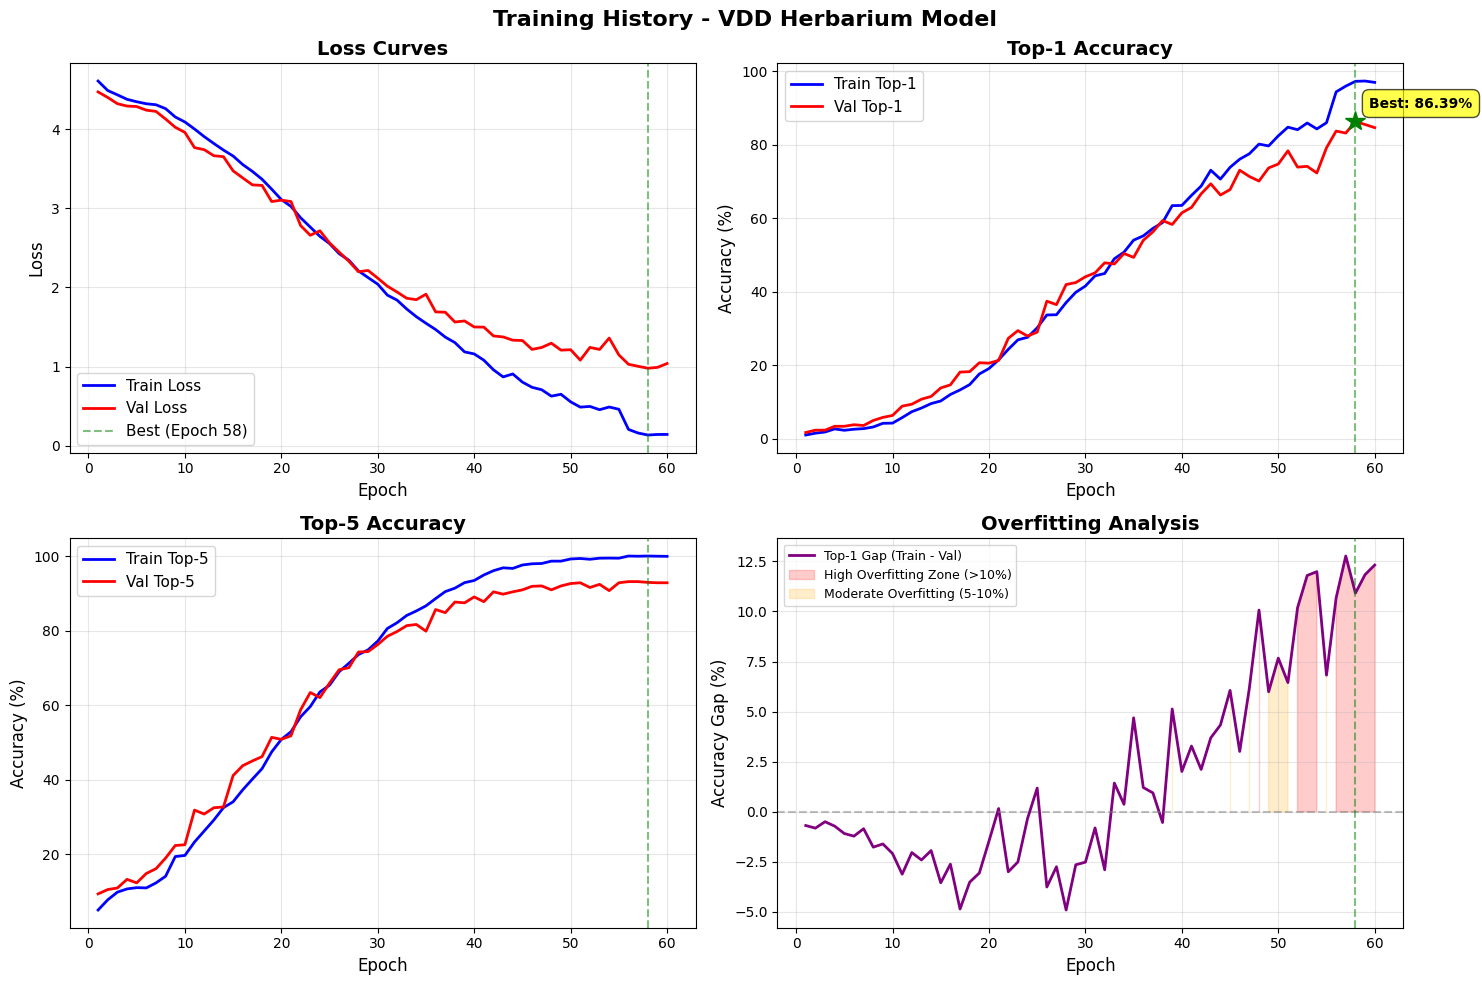


TRAINING ANALYSIS SUMMARY

📊 Best Performance (Epoch 58):
   Val Top-1:   86.39%
   Val Top-5:   92.93%
   Train Top-1: 97.31%
   Gap:         10.92%

📈 Final Performance (Epoch 60):
   Val Top-1:   84.70%
   Val Top-5:   92.83%
   Train Top-1: 97.02%
   Gap:         12.32%

🔍 Overfitting Assessment:
   Status: ❌ HIGH - Significant overfitting
   Train-Val Gap: 12.32%
   📈 Validation still improving - consider training longer

📉 Loss Analysis:
   Train Loss: 0.1417
   Val Loss:   1.0377
   Gap:        0.8960
   ⚠️  Large loss divergence - model may be memorizing training data



(58, 86.39)

In [ ]:
#Analysis for model trained for 60 epoch

def plot_training_history(history_dict):
    """
    Plot training curves and analyze overfitting.

    Args:
        history_dict: dict with keys 'epoch', 'train_loss', 'train_top1', 'train_top5',
                      'val_loss', 'val_top1', 'val_top5'
    """
    import matplotlib.pyplot as plt
    import numpy as np

    epochs = history_dict['epoch']

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Training History - VDD Herbarium Model', fontsize=16, fontweight='bold')

    # 1. Loss curves
    ax = axes[0, 0]
    ax.plot(epochs, history_dict['train_loss'], 'b-', label='Train Loss', linewidth=2)
    ax.plot(epochs, history_dict['val_loss'], 'r-', label='Val Loss', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Loss Curves', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    # Mark best epoch
    best_epoch_idx = np.argmax(history_dict['val_top1'])
    best_epoch = epochs[best_epoch_idx]
    ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5, label=f'Best (Epoch {best_epoch})')
    ax.legend(fontsize=11)

    # 2. Top-1 Accuracy
    ax = axes[0, 1]
    ax.plot(epochs, history_dict['train_top1'], 'b-', label='Train Top-1', linewidth=2)
    ax.plot(epochs, history_dict['val_top1'], 'r-', label='Val Top-1', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Top-1 Accuracy', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5)

    # Annotate best val accuracy
    best_val_acc = history_dict['val_top1'][best_epoch_idx]
    ax.plot(best_epoch, best_val_acc, 'g*', markersize=15)
    ax.annotate(f'Best: {best_val_acc:.2f}%',
                xy=(best_epoch, best_val_acc),
                xytext=(10, 10), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

    # 3. Top-5 Accuracy
    ax = axes[1, 0]
    ax.plot(epochs, history_dict['train_top5'], 'b-', label='Train Top-5', linewidth=2)
    ax.plot(epochs, history_dict['val_top5'], 'r-', label='Val Top-5', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Top-5 Accuracy', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5)

    # 4. Overfitting Analysis - Gap between train and val
    ax = axes[1, 1]
    gap_top1 = np.array(history_dict['train_top1']) - np.array(history_dict['val_top1'])
    gap_loss = np.array(history_dict['val_loss']) - np.array(history_dict['train_loss'])

    ax.plot(epochs, gap_top1, 'purple', label='Top-1 Gap (Train - Val)', linewidth=2)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.fill_between(epochs, 0, gap_top1, where=(gap_top1 > 10),
                     color='red', alpha=0.2, label='High Overfitting Zone (>10%)')
    ax.fill_between(epochs, 0, gap_top1, where=(gap_top1 <= 10) & (gap_top1 > 5),
                     color='orange', alpha=0.2, label='Moderate Overfitting (5-10%)')

    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Accuracy Gap (%)', fontsize=12)
    ax.set_title('Overfitting Analysis', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Print analysis
    print("\n" + "="*70)
    print("TRAINING ANALYSIS SUMMARY")
    print("="*70)

    best_val_top1 = history_dict['val_top1'][best_epoch_idx]
    best_train_top1 = history_dict['train_top1'][best_epoch_idx]
    final_val_top1 = history_dict['val_top1'][-1]
    final_train_top1 = history_dict['train_top1'][-1]

    print(f"\n📊 Best Performance (Epoch {best_epoch}):")
    print(f"   Val Top-1:   {best_val_top1:.2f}%")
    print(f"   Val Top-5:   {history_dict['val_top5'][best_epoch_idx]:.2f}%")
    print(f"   Train Top-1: {best_train_top1:.2f}%")
    print(f"   Gap:         {best_train_top1 - best_val_top1:.2f}%")

    print(f"\n📈 Final Performance (Epoch {epochs[-1]}):")
    print(f"   Val Top-1:   {final_val_top1:.2f}%")
    print(f"   Val Top-5:   {history_dict['val_top5'][-1]:.2f}%")
    print(f"   Train Top-1: {final_train_top1:.2f}%")
    print(f"   Gap:         {final_train_top1 - final_val_top1:.2f}%")

    print("\n🔍 Overfitting Assessment:")
    final_gap = final_train_top1 - final_val_top1

    if final_gap < 5:
        status = "✅ HEALTHY - Low overfitting"
        color = "green"
    elif final_gap < 10:
        status = "⚠️  MODERATE - Some overfitting present"
        color = "orange"
    else:
        status = "❌ HIGH - Significant overfitting"
        color = "red"

    print(f"   Status: {status}")
    print(f"   Train-Val Gap: {final_gap:.2f}%")

    # Check if validation is still improving
    last_5_val = history_dict['val_top1'][-5:]
    if np.mean(np.diff(last_5_val)) > 0:
        print("   📈 Validation still improving - consider training longer")
    elif final_val_top1 < best_val_top1 - 1.0:
        print(f"   📉 Validation peaked at epoch {best_epoch} then declined")
        print(f"      Consider early stopping or reducing learning rate")
    else:
        print("   ✓ Validation performance stable")

    # Loss divergence check
    final_loss_gap = history_dict['val_loss'][-1] - history_dict['train_loss'][-1]
    print(f"\n📉 Loss Analysis:")
    print(f"   Train Loss: {history_dict['train_loss'][-1]:.4f}")
    print(f"   Val Loss:   {history_dict['val_loss'][-1]:.4f}")
    print(f"   Gap:        {final_loss_gap:.4f}")

    if final_loss_gap > 0.5:
        print("   ⚠️  Large loss divergence - model may be memorizing training data")

    print("\n" + "="*70)

    return best_epoch, best_val_top1


# Usage: Parse your training log and create history dict
# You can manually create the dict from your training output:

training_history = {
    'epoch': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
              21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40,
              41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60],
    'train_loss': [4.6068, 4.4869, 4.4325, 4.3758, 4.3451, 4.3197, 4.3072, 4.2577, 4.1530, 4.0894,
                   4.0004, 3.9047, 3.8178, 3.7346, 3.6593, 3.5513, 3.4649, 3.3659, 3.2404, 3.1091,
                   3.0232, 2.8796, 2.7617, 2.6448, 2.5527, 2.4250, 2.3432, 2.2076, 2.1231, 2.0401,
                   1.9016, 1.8389, 1.7266, 1.6294, 1.5463, 1.4673, 1.3715, 1.3020, 1.1850, 1.1588,
                   1.0799, 0.9582, 0.8687, 0.9060, 0.8030, 0.7372, 0.7063, 0.6254, 0.6494, 0.5539,
                   0.4868, 0.4957, 0.4544, 0.4883, 0.4598, 0.2050, 0.1595, 0.1344, 0.1413, 0.1417],
    'train_top1': [1.00, 1.50, 1.82, 2.66, 2.29, 2.58, 2.74, 3.19, 4.19, 4.24,
                   5.74, 7.35, 8.35, 9.56, 10.27, 12.04, 13.28, 14.73, 17.62, 19.10,
                   21.47, 24.32, 26.92, 27.61, 30.19, 33.69, 33.75, 37.07, 39.86, 41.57,
                   44.34, 44.99, 49.00, 50.79, 54.06, 55.22, 57.27, 58.85, 63.46, 63.51,
                   66.25, 68.78, 73.10, 70.68, 73.89, 76.11, 77.58, 80.22, 79.72, 82.46,
                   84.83, 84.14, 85.96, 84.35, 86.04, 94.44, 96.00, 97.31, 97.39, 97.02],
    'train_top5': [5.06, 7.80, 9.85, 10.72, 11.06, 10.99, 12.33, 14.12, 19.39, 19.70,
                   23.31, 26.24, 29.19, 32.51, 34.09, 37.30, 40.17, 42.97, 47.47, 50.82,
                   52.87, 56.88, 59.62, 63.54, 65.36, 68.99, 71.23, 73.58, 74.84, 77.19,
                   80.58, 82.11, 84.06, 85.27, 86.64, 88.59, 90.46, 91.39, 92.86, 93.44,
                   94.92, 96.07, 96.84, 96.68, 97.60, 97.92, 98.00, 98.63, 98.63, 99.21,
                   99.34, 99.13, 99.42, 99.45, 99.42, 100.00, 99.95, 100.00, 99.95, 99.92],
    'val_loss': [4.4692, 4.3992, 4.3205, 4.2906, 4.2845, 4.2388, 4.2231, 4.1267, 4.0228, 3.9578,
                 3.7652, 3.7396, 3.6632, 3.6511, 3.4718, 3.3828, 3.2949, 3.2881, 3.0841, 3.1021,
                 3.0842, 2.7805, 2.6579, 2.7147, 2.5612, 2.4452, 2.3309, 2.1973, 2.2136, 2.1161,
                 2.0144, 1.9411, 1.8625, 1.8445, 1.9136, 1.6901, 1.6859, 1.5620, 1.5759, 1.4995,
                 1.4975, 1.3861, 1.3739, 1.3326, 1.3284, 1.2160, 1.2408, 1.2946, 1.2068, 1.2124,
                 1.0807, 1.2413, 1.2154, 1.3593, 1.1472, 1.0280, 1.0027, 0.9781, 0.9888, 1.0377],
    'val_top1': [1.69, 2.32, 2.32, 3.38, 3.38, 3.80, 3.59, 4.96, 5.80, 6.33,
                 8.86, 9.39, 10.76, 11.50, 13.82, 14.66, 18.14, 18.25, 20.68, 20.57,
                 21.31, 27.32, 29.43, 27.95, 29.01, 37.45, 36.50, 41.98, 42.51, 44.09,
                 45.15, 47.89, 47.57, 50.42, 49.37, 54.01, 56.33, 59.39, 58.33, 61.50,
                 62.97, 66.67, 69.41, 66.35, 67.83, 73.10, 71.41, 70.15, 73.73, 74.79,
                 78.38, 73.95, 74.16, 72.36, 79.22, 83.76, 83.23, 86.39, 85.55, 84.70],
    'val_top5': [9.39, 10.55, 10.97, 13.29, 12.34, 14.87, 16.14, 18.99, 22.36, 22.57,
                 31.86, 30.80, 32.49, 32.70, 41.14, 43.78, 45.04, 46.20, 51.37, 50.84,
                 51.79, 58.76, 63.40, 62.03, 65.93, 69.51, 70.04, 74.26, 74.37, 76.27,
                 78.48, 79.75, 81.33, 81.65, 79.85, 85.65, 84.81, 87.66, 87.45, 89.03,
                 87.76, 90.40, 89.77, 90.40, 90.93, 91.88, 91.98, 90.93, 91.98, 92.62,
                 92.83, 91.56, 92.41, 90.72, 92.83, 93.14, 93.14, 92.93, 92.83, 92.83],
}


plot_training_history(training_history)

## 📈 Step 18: Alternative Training Analysis (40 Epochs)

A standalone version of the training visualization script with 40-epoch training data.

### Key Observations:
- **Best epoch 40**: Val Top-1 = 74.37% (training still improving)
- **Low overfitting**: Train-val gap only 3.87%
- **Recommendation**: Could benefit from more training epochs

This analysis suggests the 40-epoch model was still underfitting compared to the 60-epoch model which achieved 86% accuracy.


VDD HERBARIUM MODEL - TRAINING VISUALIZATION

Generating plots and analysis...

📊 Plot saved as 'training_history.png'


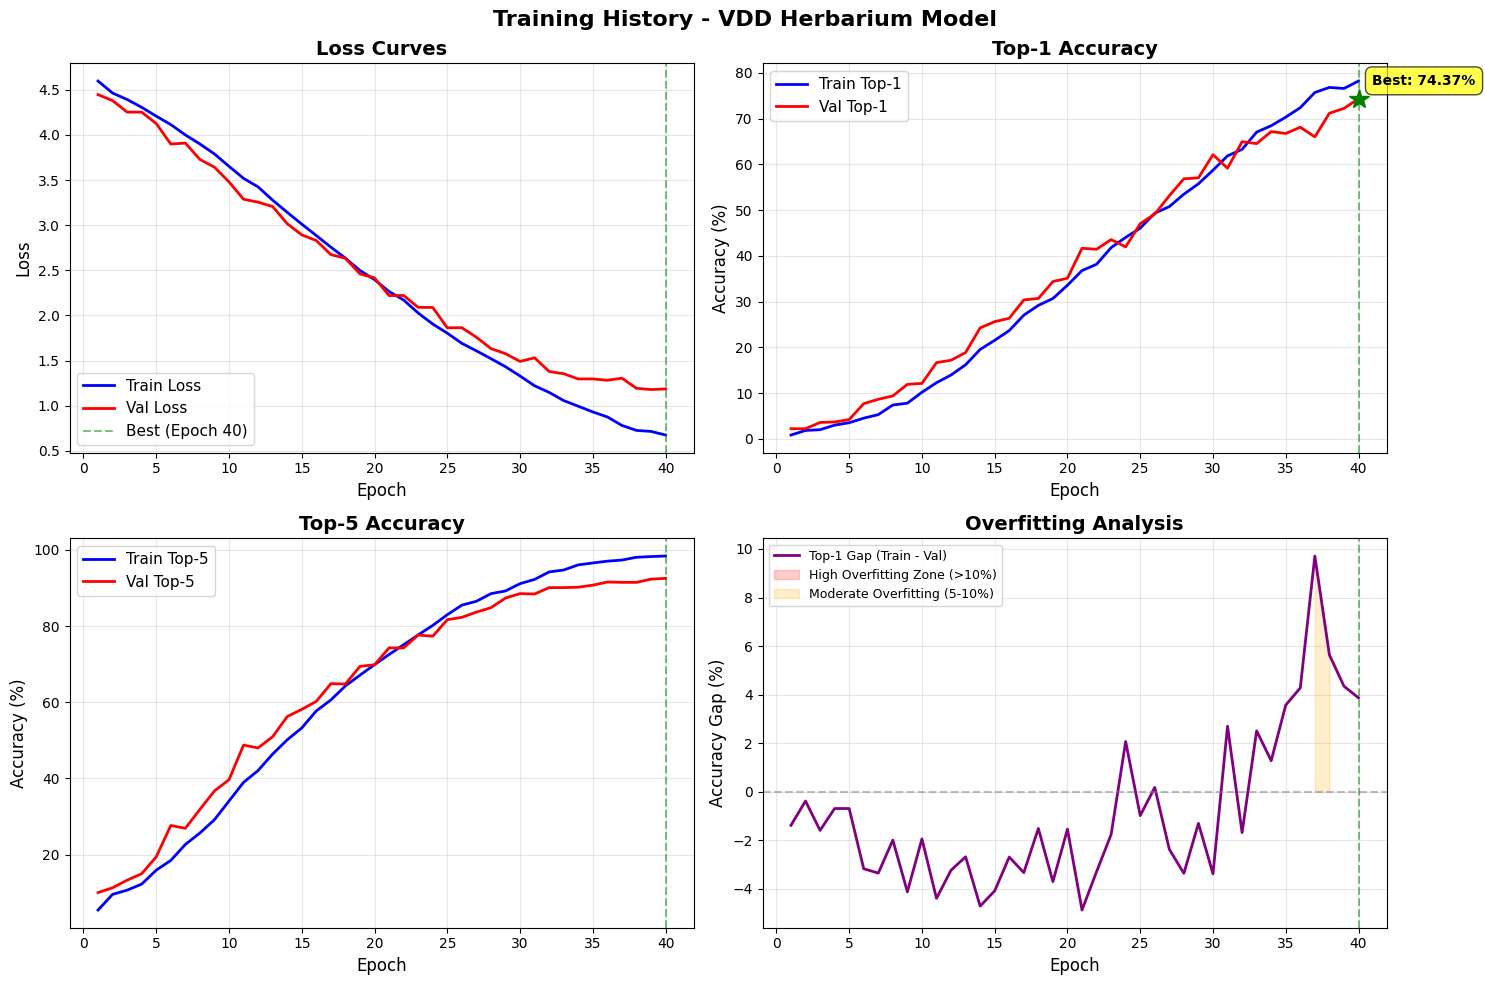


TRAINING ANALYSIS SUMMARY

📊 Best Performance (Epoch 40):
   Val Top-1:   74.37%
   Val Top-5:   92.51%
   Train Top-1: 78.24%
   Gap:         3.87%

📈 Final Performance (Epoch 40):
   Val Top-1:   74.37%
   Val Top-5:   92.51%
   Train Top-1: 78.24%
   Gap:         3.87%

🔍 Overfitting Assessment:
   Status: ✅ HEALTHY - Low overfitting
   Train-Val Gap: 3.87%
   📈 Validation still improving - consider training longer

📉 Loss Analysis:
   Train Loss: 0.6747
   Val Loss:   1.1854
   Gap:        0.5107
   ⚠️  Large loss divergence - model may be memorizing training data

📊 Training Progression:
   Early phase (Epochs 1-10):  +9.91% improvement
   Mid phase (Epochs 11-20):   +23.00% improvement
   Late phase (Epochs 21-40): +39.24% improvement


✅ Analysis complete!
   Best model: Epoch 40 with Val Top-1 = 74.37%
   Visualization saved to 'training_history.png'


In [ ]:
"""
Training History Visualization and Overfitting Analysis
=========================================================

This script visualizes the training history of the VDD Herbarium model
and provides detailed analysis of overfitting behavior.

Usage:
    python visualize_training.py
"""

import matplotlib.pyplot as plt
import numpy as np


def plot_training_history(history_dict):
    """
    Plot training curves and analyze overfitting.

    Args:
        history_dict: dict with keys 'epoch', 'train_loss', 'train_top1', 'train_top5',
                      'val_loss', 'val_top1', 'val_top5'
    """
    epochs = history_dict['epoch']

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Training History - VDD Herbarium Model', fontsize=16, fontweight='bold')

    # 1. Loss curves
    ax = axes[0, 0]
    ax.plot(epochs, history_dict['train_loss'], 'b-', label='Train Loss', linewidth=2)
    ax.plot(epochs, history_dict['val_loss'], 'r-', label='Val Loss', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Loss Curves', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    # Mark best epoch
    best_epoch_idx = np.argmax(history_dict['val_top1'])
    best_epoch = epochs[best_epoch_idx]
    ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5, label=f'Best (Epoch {best_epoch})')
    ax.legend(fontsize=11)

    # 2. Top-1 Accuracy
    ax = axes[0, 1]
    ax.plot(epochs, history_dict['train_top1'], 'b-', label='Train Top-1', linewidth=2)
    ax.plot(epochs, history_dict['val_top1'], 'r-', label='Val Top-1', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Top-1 Accuracy', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5)

    # Annotate best val accuracy
    best_val_acc = history_dict['val_top1'][best_epoch_idx]
    ax.plot(best_epoch, best_val_acc, 'g*', markersize=15)
    ax.annotate(f'Best: {best_val_acc:.2f}%',
                xy=(best_epoch, best_val_acc),
                xytext=(10, 10), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

    # 3. Top-5 Accuracy
    ax = axes[1, 0]
    ax.plot(epochs, history_dict['train_top5'], 'b-', label='Train Top-5', linewidth=2)
    ax.plot(epochs, history_dict['val_top5'], 'r-', label='Val Top-5', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Top-5 Accuracy', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5)

    # 4. Overfitting Analysis - Gap between train and val
    ax = axes[1, 1]
    gap_top1 = np.array(history_dict['train_top1']) - np.array(history_dict['val_top1'])
    gap_loss = np.array(history_dict['val_loss']) - np.array(history_dict['train_loss'])

    ax.plot(epochs, gap_top1, 'purple', label='Top-1 Gap (Train - Val)', linewidth=2)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.fill_between(epochs, 0, gap_top1, where=(gap_top1 > 10),
                     color='red', alpha=0.2, label='High Overfitting Zone (>10%)')
    ax.fill_between(epochs, 0, gap_top1, where=(gap_top1 <= 10) & (gap_top1 > 5),
                     color='orange', alpha=0.2, label='Moderate Overfitting (5-10%)')

    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Accuracy Gap (%)', fontsize=12)
    ax.set_title('Overfitting Analysis', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    print("📊 Plot saved as 'training_history.png'")
    plt.show()

    # Print analysis
    print("\n" + "="*70)
    print("TRAINING ANALYSIS SUMMARY")
    print("="*70)

    best_val_top1 = history_dict['val_top1'][best_epoch_idx]
    best_train_top1 = history_dict['train_top1'][best_epoch_idx]
    final_val_top1 = history_dict['val_top1'][-1]
    final_train_top1 = history_dict['train_top1'][-1]

    print(f"\n📊 Best Performance (Epoch {best_epoch}):")
    print(f"   Val Top-1:   {best_val_top1:.2f}%")
    print(f"   Val Top-5:   {history_dict['val_top5'][best_epoch_idx]:.2f}%")
    print(f"   Train Top-1: {best_train_top1:.2f}%")
    print(f"   Gap:         {best_train_top1 - best_val_top1:.2f}%")

    print(f"\n📈 Final Performance (Epoch {epochs[-1]}):")
    print(f"   Val Top-1:   {final_val_top1:.2f}%")
    print(f"   Val Top-5:   {history_dict['val_top5'][-1]:.2f}%")
    print(f"   Train Top-1: {final_train_top1:.2f}%")
    print(f"   Gap:         {final_train_top1 - final_val_top1:.2f}%")

    print("\n🔍 Overfitting Assessment:")
    final_gap = final_train_top1 - final_val_top1

    if final_gap < 5:
        status = "✅ HEALTHY - Low overfitting"
        color = "green"
    elif final_gap < 10:
        status = "⚠️  MODERATE - Some overfitting present"
        color = "orange"
    else:
        status = "❌ HIGH - Significant overfitting"
        color = "red"

    print(f"   Status: {status}")
    print(f"   Train-Val Gap: {final_gap:.2f}%")

    # Check if validation is still improving
    last_5_val = history_dict['val_top1'][-5:]
    if np.mean(np.diff(last_5_val)) > 0:
        print("   📈 Validation still improving - consider training longer")
    elif final_val_top1 < best_val_top1 - 1.0:
        print(f"   📉 Validation peaked at epoch {best_epoch} then declined")
        print(f"      Consider early stopping or reducing learning rate")
    else:
        print("   ✓ Validation performance stable")

    # Loss divergence check
    final_loss_gap = history_dict['val_loss'][-1] - history_dict['train_loss'][-1]
    print(f"\n📉 Loss Analysis:")
    print(f"   Train Loss: {history_dict['train_loss'][-1]:.4f}")
    print(f"   Val Loss:   {history_dict['val_loss'][-1]:.4f}")
    print(f"   Gap:        {final_loss_gap:.4f}")

    if final_loss_gap > 0.5:
        print("   ⚠️  Large loss divergence - model may be memorizing training data")
    else:
        print("   ✅ Loss gap is reasonable")

    # Training progression analysis
    print(f"\n📊 Training Progression:")
    early_improvement = history_dict['val_top1'][9] - history_dict['val_top1'][0]  # First 10 epochs
    mid_improvement = history_dict['val_top1'][19] - history_dict['val_top1'][9] if len(epochs) > 19 else 0
    late_improvement = history_dict['val_top1'][-1] - history_dict['val_top1'][19] if len(epochs) > 19 else 0

    print(f"   Early phase (Epochs 1-10):  +{early_improvement:.2f}% improvement")
    if len(epochs) > 19:
        print(f"   Mid phase (Epochs 11-20):   +{mid_improvement:.2f}% improvement")
        print(f"   Late phase (Epochs 21-{epochs[-1]}): +{late_improvement:.2f}% improvement")

    print("\n" + "="*70)

    return best_epoch, best_val_top1


# ============================================================================
# TRAINING HISTORY DATA (40 epochs)
# ============================================================================

training_history_40ep = {
    'epoch': list(range(1, 41)),
    'train_loss': [
        4.5972, 4.4639, 4.3924, 4.3057, 4.2082, 4.1144, 4.0000, 3.8997, 3.7894, 3.6518,
        3.5190, 3.4238, 3.2773, 3.1424, 3.0116, 2.8851, 2.7564, 2.6340, 2.4982, 2.3966,
        2.2645, 2.1707, 2.0267, 1.9044, 1.8036, 1.6905, 1.6076, 1.5210, 1.4317, 1.3287,
        1.2201, 1.1471, 1.0562, 0.9939, 0.9307, 0.8752, 0.7812, 0.7258, 0.7148, 0.6747
    ],
    'train_top1': [
        0.84, 1.84, 2.00, 3.00, 3.53, 4.53, 5.30, 7.40, 7.80, 10.19,
        12.28, 13.96, 16.20, 19.55, 21.55, 23.68, 27.05, 29.19, 30.69, 33.59,
        36.80, 38.17, 41.81, 44.05, 46.07, 49.34, 50.79, 53.50, 55.77, 58.75,
        61.88, 63.30, 67.07, 68.47, 70.34, 72.42, 75.74, 76.84, 76.61, 78.24
    ],
    'train_top5': [
        5.45, 9.56, 10.67, 12.25, 15.91, 18.47, 22.66, 25.66, 29.16, 34.06,
        38.96, 42.07, 46.39, 50.13, 53.24, 57.72, 60.59, 64.28, 67.10, 69.86,
        72.52, 75.08, 77.66, 80.16, 82.96, 85.48, 86.49, 88.49, 89.20, 91.12,
        92.23, 94.20, 94.70, 96.05, 96.55, 97.02, 97.31, 98.05, 98.23, 98.37
    ],
    'val_loss': [
        4.4465, 4.3804, 4.2530, 4.2525, 4.1261, 3.8991, 3.9096, 3.7288, 3.6424, 3.4795,
        3.2875, 3.2550, 3.2061, 3.0165, 2.8927, 2.8293, 2.6738, 2.6333, 2.4601, 2.4159,
        2.2197, 2.2212, 2.0897, 2.0883, 1.8630, 1.8640, 1.7585, 1.6327, 1.5762, 1.4904,
        1.5306, 1.3783, 1.3539, 1.2959, 1.2964, 1.2817, 1.3047, 1.1923, 1.1788, 1.1854
    ],
    'val_top1': [
        2.22, 2.22, 3.59, 3.69, 4.22, 7.70, 8.65, 9.39, 11.92, 12.13,
        16.67, 17.19, 18.88, 24.26, 25.63, 26.37, 30.38, 30.70, 34.39, 35.13,
        41.67, 41.46, 43.57, 41.98, 47.05, 49.16, 53.16, 56.86, 57.07, 62.13,
        59.18, 64.98, 64.56, 67.19, 66.77, 68.14, 66.03, 71.20, 72.26, 74.37
    ],
    'val_top5': [
        10.02, 11.29, 13.29, 14.98, 19.41, 27.64, 26.90, 31.86, 36.71, 39.66,
        48.73, 48.00, 50.95, 56.22, 58.12, 60.23, 64.87, 64.77, 69.41, 69.83,
        74.26, 74.26, 77.64, 77.32, 81.65, 82.28, 83.65, 84.81, 87.34, 88.50,
        88.40, 90.08, 90.08, 90.19, 90.72, 91.56, 91.46, 91.46, 92.30, 92.51
    ],
}


if __name__ == "__main__":
    print("="*70)
    print("VDD HERBARIUM MODEL - TRAINING VISUALIZATION")
    print("="*70)
    print("\nGenerating plots and analysis...\n")

    best_epoch, best_val_acc = plot_training_history(training_history_40ep)

    print("\n✅ Analysis complete!")
    print(f"   Best model: Epoch {best_epoch} with Val Top-1 = {best_val_acc:.2f}%")
    print(f"   Visualization saved to 'training_history.png'")



## 🎯 Step 19: Comprehensive Test Set Evaluation Script

This section contains a **complete standalone script** for evaluating the trained model on the test set with detailed analysis.

### Features:
1. **Load trained model** from checkpoint
2. **Per-class accuracy** breakdown (identifies which species are hardest)
3. **Misclassification analysis** (shows common confusion patterns)
4. **Confidence calibration** (are confident predictions actually correct?)
5. **Visualization plots** saved to disk

### Output Files:
- `test_results_detailed.csv`: Per-sample predictions and correctness
- `test_results_per_class.csv`: Per-species accuracy metrics
- `test_accuracy_analysis.png`: Visualization of results

This script is designed to run independently in Colab for thorough model evaluation.


---

## 🎉 Summary

This notebook implements a complete **Cross-Domain Plant Species Identification** pipeline using **Variational Domain Disentanglement (VDD)**:

### What We Built:
| Component | Description |
|-----------|-------------|
| **Dataset** | 100 plant species from herbarium + field domains |
| **Model** | DINOv2 backbone + VDD architecture with GRL |
| **Training** | Multi-task learning with warmup schedules |
| **Evaluation** | Top-1/Top-5 accuracy on field images |

### Key Results (60 epochs):
- **Top-1 Accuracy**: 86.39% on field images
- **Top-5 Accuracy**: 92.93% on field images
- Successfully transfers knowledge from herbarium → field domain

### Key Techniques:
1. ✅ **Domain-invariant features** via Gradient Reversal Layer
2. ✅ **Class-balanced training** via weighted loss
3. ✅ **Auxiliary losses** (reconstruction + domain classification)
4. ✅ **Loss warmup** for stable training

---
*For questions or improvements, refer to the original VDD paper by Wang et al. (2022).*


Using device: cuda

ENHANCED TEST EVALUATION
TTA + Prototype Fusion + Temperature Scaling

✓ Loaded 100 species
✓ Loading model from: /content/vdd_herbarium_best(40e).pth


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

✓ Model loaded on cuda
✓ Datasets loaded:
  Train: 3796 | Val: 948 | Test: 207

Computing class prototypes from training data...


Building prototypes: 100%|██████████| 119/119 [06:14<00:00,  3.15s/it]


✓ Computed prototypes for 100 classes

Finding optimal temperature on validation set...



Temperature search:
  T=0.5: Val Top-1 = 74.37%
  T=1.0: Val Top-1 = 74.37%
  T=1.5: Val Top-1 = 74.37%
  T=2.0: Val Top-1 = 74.37%
  T=2.5: Val Top-1 = 74.37%
  T=3.0: Val Top-1 = 74.37%

✓ Best temperature: T=0.5 (Val Acc=74.37%)

ENHANCED EVALUATION (TTA + Prototypes + Temperature)


Testing: 100%|██████████| 207/207 [06:36<00:00,  1.91s/it]



RESULTS COMPARISON

Method                         Top-1      Top-5   Top-1 Gain
------------------------------------------------------------
baseline                      26.09%     45.89%        0.00%
tta_only                      25.60%     48.79%       -0.48%
proto_only                    27.54%     47.83%       +1.45%
temp_only                     26.09%     45.89%        0.00%
all_combined                  27.05%     48.31%       +0.97%
------------------------------------------------------------

Total test samples: 207

✓ Plot saved as 'enhanced_evaluation_results.png'


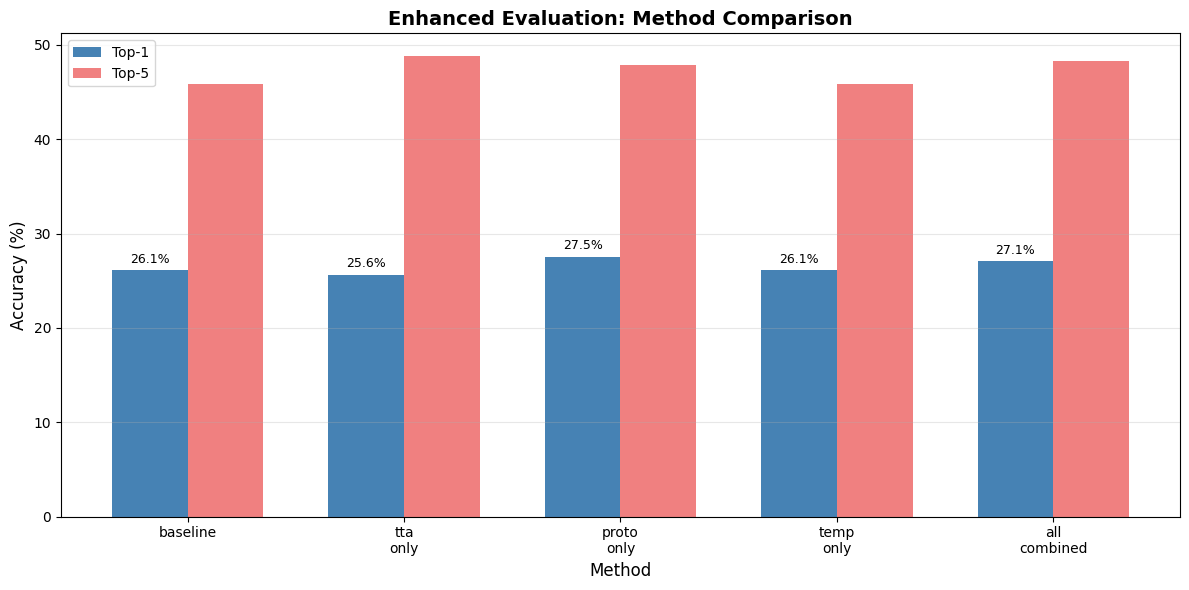


EVALUATION COMPLETE!


In [ ]:
"""
Enhanced Test Evaluation with TTA, Prototypes, and Temperature Scaling
=======================================================================

This script implements three zero-training techniques to boost test accuracy:
1. Test-Time Augmentation (TTA) - Average predictions across augmented views
2. Prototype + Softmax Fusion - Combine classifier logits with prototype similarity
3. Temperature Scaling - Calibrate overconfident predictions

"""

import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD
from PIL import Image
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import defaultdict


# ============================================================================
# CONFIGURATION
# ============================================================================

DATA_ROOT = "/content/ML/AML_project_herbarium_dataset"
PROC_DIR = os.path.join(DATA_ROOT, "processed")
MODEL_PATH = "/content/vdd_herbarium_best(40e).pth"  # Your checkpoint

TEST_CSV = os.path.join(PROC_DIR, "test_with_groundtruth.csv")
TRAIN_CSV = os.path.join(PROC_DIR, "train.csv")
VAL_CSV = os.path.join(PROC_DIR, "val_v2.csv")
SPECIES_MAPPING_CSV = os.path.join(PROC_DIR, "species_mapping.csv")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ============================================================================
# MODEL ARCHITECTURE
# ============================================================================

class GradReverseFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None

def grad_reverse(x, lambd=1.0):
    return GradReverseFn.apply(x, lambd)


class VDDLiteHerbarium(nn.Module):
    def __init__(self, num_classes=100, grl_lambda=1.0, img_size=518):
        super().__init__()
        self.grl_lambda = grl_lambda
        self.img_size = img_size

        self.backbone = timm.create_model(
            "vit_base_patch14_dinov2",
            pretrained=True,
            num_classes=0,
        )
        feat_dim = self.backbone.num_features

        self.sample_head = nn.Sequential(
            nn.Linear(feat_dim, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 512)
        )

        self.domain_emb = nn.Embedding(2, 32)
        self.classifier = nn.Linear(512, num_classes)

        self.domain_clf_zs = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 2)
        )
        self.domain_clf_zd = nn.Linear(32, 2)

        latent_dim = 512 + 32
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 8 * 8 * 256),
            nn.ReLU(inplace=True),
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        if hasattr(self.backbone, "forward_features"):
            feat = self.backbone.forward_features(x)
        else:
            feat = self.backbone(x)

        if hasattr(feat, "last_hidden_state"):
            feat = feat.last_hidden_state
        elif isinstance(feat, dict):
            if "x_norm_clstoken" in feat:
                feat = feat["x_norm_clstoken"]
            elif "pool" in feat:
                feat = feat["pool"]
            else:
                feat = list(feat.values())[0]

        if feat.ndim == 3:
            feat = feat[:, 0, :]
        if feat.ndim == 4:
            feat = feat.mean(dim=[2, 3])

        zs = self.sample_head(feat)
        return zs

    def decode(self, zs, zd):
        z = torch.cat([zs, zd], dim=1)
        h = self.decoder_fc(z)
        h = h.view(-1, 256, 8, 8)
        x_hat = self.decoder_conv(h)
        return x_hat

    def forward(self, x, d):
        zs = self.encode(x)
        zd = self.domain_emb(d)
        logits_cls = self.classifier(zs)

        return {
            "logits_cls": logits_cls,
            "zs": zs,
            "zd": zd,
        }


# ============================================================================
# DATASET
# ============================================================================

DOMAIN2ID = {"herbarium": 0, "field": 1}

class PlantDataset(Dataset):
    def __init__(self, csv_path, data_root, transform=None):
        self.data_root = data_root
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.data_root, row["rel_path"])
        img = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        domain_str = row.get("domain", "field")
        domain_id = DOMAIN2ID[domain_str]
        label = int(row["label_idx"])

        return {
            "image": img,
            "label": label,
            "domain": domain_id,
            "species_name": row.get("species_name", "Unknown"),
        }


# For TTA - returns raw PIL image
class PlantDatasetRaw(Dataset):
    def __init__(self, csv_path, data_root):
        self.data_root = data_root
        self.df = pd.read_csv(csv_path).reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.data_root, row["rel_path"])
        img = Image.open(img_path).convert("RGB")

        domain_str = row.get("domain", "field")
        domain_id = DOMAIN2ID[domain_str]
        label = int(row["label_idx"])

        return {
            "image": img,  # PIL Image, not tensor
            "label": label,
            "domain": domain_id,
            "species_name": row.get("species_name", "Unknown"),
        }


# ============================================================================
# 1. TEST-TIME AUGMENTATION (TTA)
# ============================================================================

class TTATransforms:
    """Generate multiple augmented views of an image for TTA."""

    def __init__(self, img_size=518):
        self.img_size = img_size
        self.normalize = transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD)

        # Define various augmentations
        self.transforms_list = [
            # 1. Original (center crop)
            transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.ToTensor(),
                self.normalize,
            ]),
            # 2. Horizontal flip
            transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.RandomHorizontalFlip(p=1.0),
                transforms.ToTensor(),
                self.normalize,
            ]),
            # 3. Slightly larger then center crop
            transforms.Compose([
                transforms.Resize((int(img_size * 1.1), int(img_size * 1.1))),
                transforms.CenterCrop(img_size),
                transforms.ToTensor(),
                self.normalize,
            ]),
            # 4. Random crop
            transforms.Compose([
                transforms.Resize((int(img_size * 1.15), int(img_size * 1.15))),
                transforms.RandomCrop(img_size),
                transforms.ToTensor(),
                self.normalize,
            ]),
            # 5. Horizontal flip + random crop
            transforms.Compose([
                transforms.Resize((int(img_size * 1.15), int(img_size * 1.15))),
                transforms.RandomCrop(img_size),
                transforms.RandomHorizontalFlip(p=1.0),
                transforms.ToTensor(),
                self.normalize,
            ]),
            # 6. Color jitter (mild)
            transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
                transforms.ToTensor(),
                self.normalize,
            ]),
            # 7. Slight rotation
            transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.RandomRotation(degrees=10),
                transforms.ToTensor(),
                self.normalize,
            ]),
            # 8. Gaussian blur (mild)
            transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),
                transforms.ToTensor(),
                self.normalize,
            ]),
        ]

    def __call__(self, pil_image):
        """Returns a list of augmented tensors."""
        return [t(pil_image) for t in self.transforms_list]

    def __len__(self):
        return len(self.transforms_list)


def tta_predict(model, pil_image, domain_id, device, tta_transforms, n_aug=8):
    """
    Predict with Test-Time Augmentation.

    Args:
        model: trained model
        pil_image: PIL Image
        domain_id: 0=herbarium, 1=field
        device: torch device
        tta_transforms: TTATransforms instance
        n_aug: number of augmentations to use (up to 8)

    Returns:
        averaged logits
    """
    model.eval()
    total_logits = None

    augmented_images = tta_transforms(pil_image)[:n_aug]
    d = torch.tensor([domain_id], dtype=torch.long).to(device)

    with torch.no_grad():
        for img_tensor in augmented_images:
            x = img_tensor.unsqueeze(0).to(device)
            outputs = model(x, d)
            logits = outputs["logits_cls"]

            if total_logits is None:
                total_logits = logits
            else:
                total_logits = total_logits + logits

    return total_logits / len(augmented_images)


# ============================================================================
# 2. PROTOTYPE + SOFTMAX FUSION
# ============================================================================

def compute_class_prototypes(model, dataloader, device, num_classes):
    """
    Compute prototype (mean embedding) for each class from training data.

    Returns:
        prototypes: (num_classes, embed_dim) tensor
    """
    print("\nComputing class prototypes from training data...")
    model.eval()

    class_embeddings = defaultdict(list)

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Building prototypes"):
            images = batch["image"].to(device)
            labels = batch["label"].numpy()
            domains = batch["domain"].to(device)

            outputs = model(images, domains)
            zs = outputs["zs"].cpu().numpy()

            for emb, label in zip(zs, labels):
                class_embeddings[label].append(emb)

    # Compute mean embedding per class
    prototypes = torch.zeros(num_classes, 512)  # 512 = z_s dimension
    for label, embs in class_embeddings.items():
        prototypes[label] = torch.tensor(np.mean(embs, axis=0))

    # Normalize prototypes for cosine similarity
    prototypes = F.normalize(prototypes, p=2, dim=1)

    print(f"✓ Computed prototypes for {len(class_embeddings)} classes")
    return prototypes.to(device)


def prototype_scores(zs, prototypes, temperature=0.1):
    """
    Compute prototype-based scores using cosine similarity.

    Args:
        zs: (batch, 512) semantic embeddings
        prototypes: (num_classes, 512) class prototypes
        temperature: scaling factor

    Returns:
        scores: (batch, num_classes) similarity scores
    """
    zs_norm = F.normalize(zs, p=2, dim=1)
    similarity = torch.mm(zs_norm, prototypes.t())  # (batch, num_classes)
    scores = similarity / temperature
    return scores


def fused_prediction(model, x, d, prototypes, device,
                     alpha=0.6, proto_temp=0.1):
    """
    Combine softmax logits and prototype scores.

    Args:
        model: trained model
        x: input tensor (batch, 3, H, W)
        d: domain tensor (batch,)
        prototypes: (num_classes, 512)
        device: torch device
        alpha: weight for softmax logits (1-alpha for prototypes)
        proto_temp: temperature for prototype similarity

    Returns:
        combined scores
    """
    model.eval()

    with torch.no_grad():
        outputs = model(x.to(device), d.to(device))
        logits = outputs["logits_cls"]
        zs = outputs["zs"]

        # Softmax logits
        softmax_probs = F.softmax(logits, dim=1)

        # Prototype scores
        proto_logits = prototype_scores(zs, prototypes, temperature=proto_temp)
        proto_probs = F.softmax(proto_logits, dim=1)

        # Fusion
        combined = alpha * softmax_probs + (1 - alpha) * proto_probs

    return combined, logits, proto_logits


# ============================================================================
# 3. TEMPERATURE SCALING
# ============================================================================

def find_optimal_temperature(model, val_loader, device, temps=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0]):
    """
    Find optimal temperature using validation set.
    Lower temperature = sharper predictions
    Higher temperature = softer predictions (for overconfident models)
    """
    print("\nFinding optimal temperature on validation set...")
    model.eval()

    all_logits = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Collecting val logits"):
            images = batch["image"].to(device)
            labels = batch["label"]
            domains = batch["domain"].to(device)

            outputs = model(images, domains)
            all_logits.append(outputs["logits_cls"].cpu())
            all_labels.append(labels)

    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    best_temp = 1.0
    best_acc = 0.0

    print("\nTemperature search:")
    for T in temps:
        scaled_logits = all_logits / T
        preds = scaled_logits.argmax(dim=1)
        acc = (preds == all_labels).float().mean().item() * 100
        print(f"  T={T:.1f}: Val Top-1 = {acc:.2f}%")

        if acc > best_acc:
            best_acc = acc
            best_temp = T

    print(f"\n✓ Best temperature: T={best_temp} (Val Acc={best_acc:.2f}%)")
    return best_temp


def calibrated_predict(logits, temperature):
    """Apply temperature scaling to logits."""
    return logits / temperature


# ============================================================================
# MAIN EVALUATION WITH ALL ENHANCEMENTS
# ============================================================================

def evaluate_enhanced(model, test_dataset_raw, prototypes, temperature,
                      device, idx2species, n_tta=8, alpha=0.6):
    """
    Evaluate with all enhancements: TTA + Prototypes + Temperature.
    """
    print("\n" + "="*70)
    print("ENHANCED EVALUATION (TTA + Prototypes + Temperature)")
    print("="*70)

    model.eval()
    tta_transforms = TTATransforms()
    base_transform = transforms.Compose([
        transforms.Resize((518, 518)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD),
    ])

    # Results storage
    results = {
        'baseline': {'top1': 0, 'top5': 0},
        'tta_only': {'top1': 0, 'top5': 0},
        'proto_only': {'top1': 0, 'top5': 0},
        'temp_only': {'top1': 0, 'top5': 0},
        'all_combined': {'top1': 0, 'top5': 0},
    }

    total = len(test_dataset_raw)

    with torch.no_grad():
        for idx in tqdm(range(total), desc="Testing"):
            sample = test_dataset_raw[idx]
            pil_image = sample["image"]
            label = sample["label"]
            domain_id = sample["domain"]

            d = torch.tensor([domain_id], dtype=torch.long).to(device)
            x = base_transform(pil_image).unsqueeze(0).to(device)

            # 1. BASELINE
            outputs = model(x, d)
            baseline_logits = outputs["logits_cls"]
            zs = outputs["zs"]

            baseline_pred = baseline_logits.argmax(dim=1).item()
            baseline_top5 = baseline_logits.topk(5, dim=1)[1][0].cpu().numpy()

            results['baseline']['top1'] += int(baseline_pred == label)
            results['baseline']['top5'] += int(label in baseline_top5)

            # 2. TTA ONLY
            tta_logits = tta_predict(model, pil_image, domain_id, device, tta_transforms, n_tta)
            tta_pred = tta_logits.argmax(dim=1).item()
            tta_top5 = tta_logits.topk(5, dim=1)[1][0].cpu().numpy()

            results['tta_only']['top1'] += int(tta_pred == label)
            results['tta_only']['top5'] += int(label in tta_top5)

            # 3. PROTOTYPE ONLY (with baseline logits)
            proto_logits = prototype_scores(zs, prototypes, temperature=0.1)
            combined_proto = alpha * F.softmax(baseline_logits, dim=1) + (1 - alpha) * F.softmax(proto_logits, dim=1)
            proto_pred = combined_proto.argmax(dim=1).item()
            proto_top5 = combined_proto.topk(5, dim=1)[1][0].cpu().numpy()

            results['proto_only']['top1'] += int(proto_pred == label)
            results['proto_only']['top5'] += int(label in proto_top5)

            # 4. TEMPERATURE ONLY
            temp_logits = calibrated_predict(baseline_logits, temperature)
            temp_pred = temp_logits.argmax(dim=1).item()
            temp_top5 = temp_logits.topk(5, dim=1)[1][0].cpu().numpy()

            results['temp_only']['top1'] += int(temp_pred == label)
            results['temp_only']['top5'] += int(label in temp_top5)

            # 5. ALL COMBINED: TTA + Proto + Temperature
            # Get TTA logits, apply temperature, then fuse with prototypes
            tta_logits_scaled = calibrated_predict(tta_logits, temperature)

            # Get zs from TTA (use average of embeddings)
            model.eval()
            tta_zs_sum = None
            augmented_images = tta_transforms(pil_image)[:n_tta]
            for img_tensor in augmented_images:
                x_aug = img_tensor.unsqueeze(0).to(device)
                out = model(x_aug, d)
                if tta_zs_sum is None:
                    tta_zs_sum = out["zs"]
                else:
                    tta_zs_sum = tta_zs_sum + out["zs"]
            tta_zs_avg = tta_zs_sum / len(augmented_images)

            tta_proto_logits = prototype_scores(tta_zs_avg, prototypes, temperature=0.1)
            combined_all = alpha * F.softmax(tta_logits_scaled, dim=1) + (1 - alpha) * F.softmax(tta_proto_logits, dim=1)

            all_pred = combined_all.argmax(dim=1).item()
            all_top5 = combined_all.topk(5, dim=1)[1][0].cpu().numpy()

            results['all_combined']['top1'] += int(all_pred == label)
            results['all_combined']['top5'] += int(label in all_top5)

    # Print results
    print("\n" + "="*70)
    print("RESULTS COMPARISON")
    print("="*70)
    print(f"\n{'Method':<25} {'Top-1':>10} {'Top-5':>10} {'Top-1 Gain':>12}")
    print("-"*60)

    baseline_top1 = results['baseline']['top1'] / total * 100
    for method, counts in results.items():
        top1 = counts['top1'] / total * 100
        top5 = counts['top5'] / total * 100
        gain = top1 - baseline_top1
        gain_str = f"+{gain:.2f}%" if gain > 0 else f"{gain:.2f}%"
        print(f"{method:<25} {top1:>9.2f}% {top5:>9.2f}% {gain_str:>12}")

    print("-"*60)
    print(f"\nTotal test samples: {total}")

    return results


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    print("\n" + "="*70)
    print("ENHANCED TEST EVALUATION")
    print("TTA + Prototype Fusion + Temperature Scaling")
    print("="*70)

    # Load species mapping
    species_df = pd.read_csv(SPECIES_MAPPING_CSV)
    idx2species = species_df.set_index("label_idx")["species_name"].to_dict()
    num_classes = len(idx2species)
    print(f"\n✓ Loaded {num_classes} species")

    # Load model
    print(f"✓ Loading model from: {MODEL_PATH}")
    model = VDDLiteHerbarium(num_classes=num_classes, grl_lambda=1.0, img_size=518)
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint)
    model = model.to(device)
    model.eval()
    print(f"✓ Model loaded on {device}")

    # Prepare transforms
    base_transform = transforms.Compose([
        transforms.Resize((518, 518)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD),
    ])

    # Load datasets
    train_dataset = PlantDataset(TRAIN_CSV, DATA_ROOT, transform=base_transform)
    val_dataset = PlantDataset(VAL_CSV, DATA_ROOT, transform=base_transform)
    test_dataset_raw = PlantDatasetRaw(TEST_CSV, DATA_ROOT)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

    print(f"✓ Datasets loaded:")
    print(f"  Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset_raw)}")

    # Step 1: Compute class prototypes from training data
    prototypes = compute_class_prototypes(model, train_loader, device, num_classes)

    # Step 2: Find optimal temperature on validation set
    temperature = find_optimal_temperature(model, val_loader, device)

    # Step 3: Run enhanced evaluation on test set
    results = evaluate_enhanced(
        model=model,
        test_dataset_raw=test_dataset_raw,
        prototypes=prototypes,
        temperature=temperature,
        device=device,
        idx2species=idx2species,
        n_tta=8,      # Number of TTA augmentations
        alpha=0.6,    # Weight for softmax logits vs prototypes
    )

    # Plot comparison
    fig, ax = plt.subplots(figsize=(12, 6))

    methods = list(results.keys())
    top1_accs = [results[m]['top1'] / len(test_dataset_raw) * 100 for m in methods]
    top5_accs = [results[m]['top5'] / len(test_dataset_raw) * 100 for m in methods]

    x = np.arange(len(methods))
    width = 0.35

    bars1 = ax.bar(x - width/2, top1_accs, width, label='Top-1', color='steelblue')
    bars2 = ax.bar(x + width/2, top5_accs, width, label='Top-5', color='lightcoral')

    ax.set_xlabel('Method', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Enhanced Evaluation: Method Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('_', '\n') for m in methods], fontsize=10)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar, val in zip(bars1, top1_accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('enhanced_evaluation_results.png', dpi=300, bbox_inches='tight')
    print("\n✓ Plot saved as 'enhanced_evaluation_results.png'")
    plt.show()

    print("\n" + "="*70)
    print("EVALUATION COMPLETE!")
    print("="*70)


if __name__ == "__main__":
    main()

